# **QBUS6810 E-Commerce prediction code**

For Olist business problem, we aim to forecast how long the average delivery time to take for unseen customers. We use machine learning to find pattern and prediction. We clean data and select features to bulid several models and select the best model with stacking.

# **1. Clean and Merge dataset for define business problem**

In [4]:
!pip install optuna

In [5]:
import warnings

# Global Settings
warnings.filterwarnings("ignore")

In [6]:
import pandas as pd

# Read geolocation dataset
df = pd.read_csv("olist_geolocation_dataset.csv")

# Define the range of Brazil's longitude and latitude
LAT_MIN, LAT_MAX = -34.0, 5.5
LNG_MIN, LNG_MAX = -74.0, -34.0

# Check number of out-of-range values
invalid_lat = df[(df['geolocation_lat'] < LAT_MIN) | (df['geolocation_lat'] > LAT_MAX)]
invalid_lng = df[(df['geolocation_lng'] < LNG_MIN) | (df['geolocation_lng'] > LNG_MAX)]

print(f"Number of invalid latitude values: {len(invalid_lat)}")
print(f"Number of invalid longitude values: {len(invalid_lng)}")

# Clean data by removing out-of-range coordinates
df_cleaned = df[
    (df['geolocation_lat'].between(LAT_MIN, LAT_MAX)) &
    (df['geolocation_lng'].between(LNG_MIN, LNG_MAX))
]

print(f"Before cleaning: {df.shape}, After cleaing: {df_cleaned.shape}")
df_cleaned.info()

Number of invalid latitude values: 31
Number of invalid longitude values: 37
Before cleaning: (1000163, 5), After cleaing: (1000121, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 1000121 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000121 non-null  int64  
 1   geolocation_lat              1000121 non-null  float64
 2   geolocation_lng              1000121 non-null  float64
 3   geolocation_city             1000121 non-null  object 
 4   geolocation_state            1000121 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 45.8+ MB


We aim to read geolocation data and drop outliners according to Brazil's longitude and latitude.

In [8]:
import pandas as pd
import numpy as np
from collections import Counter
# Read data
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

# Translate product name
products = products.merge(
    translation[['product_category_name', 'product_category_name_english']],
    on='product_category_name', how='left'
)

# Caculate target variable — calculate order-level delivery_time_days
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')

orders = orders.dropna(subset=['order_purchase_timestamp', 'order_delivered_customer_date']).copy()
orders['delivery_time_days'] = (
    (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400.0
)
# remove obviously abnormal values
orders = orders[orders['delivery_time_days'].between(0, 180)]

# Order item details — aggregate to order level first
# 1. Merge product and seller information into each order item row
oi = (order_items
      .merge(products[['product_id','product_category_name','product_category_name_english',
                       'product_weight_g','product_length_cm','product_height_cm','product_width_cm']],
             on='product_id', how='left')
      .merge(sellers[['seller_id','seller_zip_code_prefix','seller_city','seller_state']],
             on='seller_id', how='left')
     )

# 2. Calculate product volume
if {'product_length_cm','product_height_cm','product_width_cm'}.issubset(oi.columns):
    oi['product_volume_cm3'] = (
        oi['product_length_cm'].astype(float) *
        oi['product_height_cm'].astype(float) *
        oi['product_width_cm'].astype(float)
    )
else:
    oi['product_volume_cm3'] = np.nan

# 3. Define a “mode” function
def safe_mode(s):
    s = s.dropna()
    return s.value_counts().index[0] if len(s) else np.nan

# 4. Order aggregation
agg_num = oi.groupby('order_id').agg({
    'order_item_id': 'count',              # Number of items
    'product_id': pd.Series.nunique,       # Number of unique products
    'seller_id': pd.Series.nunique,        # Number of unique sellers
    'price': 'sum',
    'freight_value': 'sum',
    'product_weight_g': ['sum'],
    'product_volume_cm3': ['sum'],
}).copy()

# Flatten column names
agg_num.columns = ['_'.join([c for c in tup if c]).replace('__','_') for tup in agg_num.columns.to_flat_index()]
agg_num = agg_num.rename(columns={
    'order_item_id_count':'items_count',
    'product_id_nunique':'n_products',
    'seller_id_nunique':'n_sellers',
    'price_sum':'price_sum',
    'freight_value_sum':'freight_sum',
    'product_weight_g_sum':'product_weight_g_sum',
    'product_volume_cm3_sum':'product_volume_cm3_sum',
})

# Category mode (main product category / main seller region)）
agg_cat = oi.groupby('order_id').agg({
    'product_category_name': safe_mode,
    'product_category_name_english': safe_mode,
    'seller_zip_code_prefix': safe_mode,
    'seller_city': safe_mode,
    'seller_state': safe_mode,
}).rename(columns={
    'product_category_name':'main_product_category_name',
    'product_category_name_english':'main_product_category_name_en',
    'seller_zip_code_prefix': 'main_seller_zip_code_prefix',
    'seller_city':'main_seller_city',
    'seller_state':'main_seller_state',
})

# Combine numeric and categorical aggregation results
order_items_agg = agg_num.join(agg_cat, how='left')

# Reset index column for easier merge
order_items_agg = order_items_agg.reset_index()

print("order_items_agg created successfully, sample below:")
order_items_agg.head()

# Payment table: aggregate to order level
payments_agg = payments.groupby('order_id').agg({
    'payment_value':'sum',
    'payment_installments':'max',
    'payment_type': safe_mode,
}).rename(columns={
    'payment_value':'payment_value_sum',
    'payment_installments':'payment_installments_max',
    'payment_type':'main_payment_type'
}).reset_index()

# Build order-level master table (no duplication)
df_order_level = (orders
    .merge(customers, on='customer_id', how='left')
    .merge(order_items_agg, on='order_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
)

# Use geolocation to map and calculate distance (add one new column only)
# New feature: customer_seller_distance_km
geo = pd.read_csv('olist_geolocation_dataset.csv')

# Standardize ZIP code prefixes to 5-character strings (avoid losing leading zeros / type mismatch)
def norm_zip(s):
    s = pd.Series(s, dtype="object")
    s = s.astype(str).str.extract(r'(\d+)')[0].fillna('')
    return s.str.zfill(5)

geo['geolocation_zip_code_prefix'] = norm_zip(geo['geolocation_zip_code_prefix'])
df_order_level['customer_zip_code_prefix'] = norm_zip(df_order_level['customer_zip_code_prefix'])
df_order_level['main_seller_zip_code_prefix'] = norm_zip(df_order_level['main_seller_zip_code_prefix'])

# Take average latitude and longitude for each ZIP code prefix
geo_mean = (geo.groupby('geolocation_zip_code_prefix', as_index=False)
              [['geolocation_lat','geolocation_lng']].mean()
              .rename(columns={
                  'geolocation_zip_code_prefix':'zip_code_prefix',
                  'geolocation_lat':'lat',
                  'geolocation_lng':'lng'
              }))

# Merge customers’ and sellers’ latitude & longitude
df_order_level = (df_order_level
    .merge(geo_mean.rename(columns={'zip_code_prefix':'customer_zip_code_prefix',
                                   'lat':'customer_lat','lng':'customer_lng'}),
           on='customer_zip_code_prefix', how='left')
    .merge(geo_mean.rename(columns={'zip_code_prefix':'main_seller_zip_code_prefix',
                                   'lat':'seller_lat','lng':'seller_lng'}),
           on='main_seller_zip_code_prefix', how='left')
)

# Haversine great-circle distance (km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df_order_level['customer_seller_distance_km'] = haversine(
    df_order_level['customer_lat'], df_order_level['customer_lng'],
    df_order_level['seller_lat'], df_order_level['seller_lng']
)


# Drop latitude/longitude columns
df_order_level.drop(columns=['customer_lat','customer_lng','seller_lat','seller_lng'], inplace=True)

df_order_level.to_csv('olist_merged_order_level.csv', index=False)

print('Merge completed (order-level, no duplicates)', df_order_level.shape)
df_order_level.head()
df_order_level.info()

order_items_agg created successfully, sample below:
Merge completed (order-level, no duplicates) (96462, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96462 entries, 0 to 96461
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96462 non-null  object        
 1   customer_id                    96462 non-null  object        
 2   order_status                   96462 non-null  object        
 3   order_purchase_timestamp       96462 non-null  datetime64[ns]
 4   order_approved_at              96448 non-null  object        
 5   order_delivered_carrier_date   96461 non-null  object        
 6   order_delivered_customer_date  96462 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96462 non-null  object        
 8   delivery_time_days             96462 non-null  float64       
 9   customer_unique_id             96462 non

We define our target variable, translate product name to English and merge products' and sellers' information based on ```order_items```. Then, we calculate volumes of product based on height, width and length. To aviod raising errors during aggregation, we create ```safe_mode``` function to make our aggregation more stable. After that, we merge our main information for prediction and connect with ```order_id```. In addition, we map and calculate distance by using geolocation and create new feature ```customer_seller_distance_km```. Finally, we drop ```customer_lat``` ```customer_lng``` ```seller_lat``` ```seller_lng``` and create new csv file.
















# **2. Exploratory Data Analysis (Cleaning data and Visualization)**

In [11]:
# Olist — Cleaning Pipeline (Random Split, No New Columns, With Stepwise Logs)

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

# Paths & Parameters
IN_FILE = Path("olist_merged_order_level.csv")
OUTDIR = Path("./clean_outputs"); OUTDIR.mkdir(exist_ok=True, parents=True)

RANDOM_STATE   = 42
TEST_SIZE      = 0.2
MAX_DAYS       = 120          # Module B: time logic threshold (rows with invalid durations will be dropped)
ITEMS_COUNT_MAX= 5            # Module A: remove rows with extreme item counts (>5); comment out if not needed
ENCODING       = "utf-8-sig"
ENCODING       = "utf-8-sig"

assert IN_FILE.exists(), f"Missing {IN_FILE}"
print("Input found:", IN_FILE.name)

# Load & Basic parse
df = pd.read_csv(IN_FILE, low_memory=False)
print(df.shape)

# Convert timestamp columns (no new columns added)
for c in [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Compute label if missing (can comment out if already exists)
if "delivery_time_days" not in df.columns:
    if {"order_delivered_customer_date","order_purchase_timestamp"} <= set(df.columns):
        df["delivery_time_days"] = (
            df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
        ).dt.total_seconds()/86400.0
    else:
        raise ValueError("delivery_time_days missing and cannot be computed.")

# Random Split
train, test = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)
print("Train/Test sizes:", train.shape, test.shape)


# Fit thresholds on TRAIN ONLY (for reproducibility)
def fit_thresholds(train: pd.DataFrame):
    th = {}
    # A: winsorize price_sum only (not drop rows)
    if "price_sum" in train.columns:
        lo, hi = train["price_sum"].quantile([0.005, 0.995]).astype(float)
        th["price_sum_lo"], th["price_sum_hi"] = float(lo), float(hi)
    # C: volume filter using p99
    if "product_volume_cm3_sum" in train.columns:
        th["volume_p99"] = float(train["product_volume_cm3_sum"].quantile(0.99))
    # Other heavy-tailed columns: 0.5%–99.5% winsorization (no new columns)
    for c in ["freight_sum","product_weight_g_sum"]:
        if c in train.columns:
            lo, hi = train[c].quantile([0.005, 0.995]).astype(float)
            th[f"{c}_lo"], th[f"{c}_hi"] = float(lo), float(hi)
    return th

thresholds = fit_thresholds(train)
print("Fitted thresholds:", thresholds)


# Module A — Customer & Amount (no new columns; winsorize price)
def clean_module_a(df_in: pd.DataFrame, th: dict) -> pd.DataFrame:
    before = len(df_in)
    df = df_in.copy()

    # price_sum winsorize（no new columns; winsorize price）
    if "price_sum" in df.columns and "price_sum_lo" in th and "price_sum_hi" in th:
        df["price_sum"] = df["price_sum"].clip(lower=th["price_sum_lo"], upper=th["price_sum_hi"])

    # Remove rows with excessive item counts (>5).
    if "items_count" in df.columns:
        df = df[df["items_count"] <= ITEMS_COUNT_MAX].copy()

    after = len(df)
    print(f"[A] Customer/Price: {before} → {after}  (-{before-after})")
    return df

# Module B — Time logic (drop invalid rows; no new columns)
def drop_time_problems(df_in: pd.DataFrame) -> pd.DataFrame:
    before = len(df_in)
    df = df_in.copy()
    mask = pd.Series(False, index=df.index)

    pairs = [
        ("order_delivered_carrier_date","order_purchase_timestamp"),
        ("order_delivered_customer_date","order_delivered_carrier_date"),
        ("order_delivered_customer_date","order_purchase_timestamp"),
    ]
    for later, earlier in pairs:
        if later in df.columns and earlier in df.columns:
            dur = (df[later] - df[earlier]).dt.total_seconds()/86400.0
            mask |= df[later].isna() | df[earlier].isna() | (dur < 0) | (dur > MAX_DAYS)

    df = df.loc[~mask].copy()
    after = len(df)
    print(f"[B] Time logic: {before} → {after}  (-{before-after})")
    return df

# Module C — Product (volume filter + winsorize numeric; no new columns)
def clean_module_c(df_in: pd.DataFrame, th: dict) -> pd.DataFrame:
    before = len(df_in)
    df = df_in.copy()

    # Filter by volume p99
    if "product_volume_cm3_sum" in df.columns and "volume_p99" in th:
        df = df[df["product_volume_cm3_sum"] <= th["volume_p99"]].copy()

    # Winsorize other heavy-tailed columns
    for c in ["freight_sum","product_weight_g_sum"]:
        lo_key, hi_key = f"{c}_lo", f"{c}_hi"
        if c in df.columns and lo_key in th and hi_key in th:
            df[c] = df[c].clip(lower=th[lo_key], upper=th[hi_key])

    after = len(df)
    print(f"[C] Product: {before} → {after}  (-{before-after})")
    return df

# Module D — Seller (normalize casing only; no new columns)
def clean_module_d(df_in: pd.DataFrame) -> pd.DataFrame:
    before = len(df_in)
    df = df_in.copy()

    # String normalization for state/city columns
    if "main_seller_state" in df.columns:
        df["main_seller_state"] = df["main_seller_state"].astype(str).str.upper().str.strip()
    if "customer_state" in df.columns:
        df["customer_state"] = df["customer_state"].astype(str).str.upper().str.strip()
    if "main_seller_city" in df.columns:
        df["main_seller_city"] = df["main_seller_city"].astype(str).str.lower().str.strip()

    after = len(df)
    print(f"[D] Seller: {before} → {after}  (-{before-after})")
    return df

# Module E — Payment (fill/clip only; no new columns)
def clean_module_e(df_in: pd.DataFrame) -> pd.DataFrame:
    before = len(df_in)
    df = df_in.copy()

    if "payment_installments_max" in df.columns:
        df["payment_installments_max"] = df["payment_installments_max"].fillna(1).clip(1, 24).astype("int16")
    if "main_payment_type" in df.columns:
        df["main_payment_type"] = df["main_payment_type"].fillna("not_defined")
    # Handle missing payment_value_sum (core addition)
    if "payment_value_sum" in df.columns:
        median_val = df["payment_value_sum"].median()
        df["payment_value_sum"] = df["payment_value_sum"].fillna(median_val)

    after = len(df)
    print(f"[E] Payment: {before} → {after}  (-{before-after})")
    return df

# Module F — Distance (fill and clip; no new columns)
def clean_module_f(df_in: pd.DataFrame) -> pd.DataFrame:
    before = len(df_in)
    df = df_in.copy()

    if "customer_seller_distance_km" in df.columns:
        # # Fill missing values with median
        median_val = df["customer_seller_distance_km"].median()
        df["customer_seller_distance_km"] = df["customer_seller_distance_km"].fillna(median_val)

        # Clip extreme values, e.g., limit to [0, 2000] km
        df["customer_seller_distance_km"] = df["customer_seller_distance_km"].clip(0, 2000)

    after = len(df)
    print(f"[F] Distance: {before} → {after} (−{before - after})")
    return df


# Run pipeline per split
def run_pipeline(df_split: pd.DataFrame, name: str) -> pd.DataFrame:
    x = clean_module_a(df_split, thresholds)
    x = drop_time_problems(x)
    x = clean_module_c(x, thresholds)
    x = clean_module_d(x)
    x = clean_module_e(x)
    x = clean_module_f(x)
    return x

train_clean = run_pipeline(train, "train")
test_clean  = run_pipeline(test , "test")

# Export
train_clean.to_csv(OUTDIR/"final_train_clean.csv", index=False, encoding=ENCODING)
test_clean.to_csv(OUTDIR/"final_test_clean.csv", index=False, encoding=ENCODING)

print(" -", (OUTDIR/'final_train_clean.csv').as_posix(), train_clean.shape)
print(" -", (OUTDIR/'final_test_clean.csv').as_posix(), test_clean.shape)
train_clean.info()

Input found: olist_merged_order_level.csv
(96462, 29)
Train/Test sizes: (77169, 29) (19293, 29)
Fitted thresholds: {'price_sum_lo': 9.9, 'price_sum_hi': 1350.0, 'volume_p99': 134505.0, 'freight_sum_lo': 7.39, 'freight_sum_hi': 136.25560000000144, 'product_weight_g_sum_lo': 50.0, 'product_weight_g_sum_hi': 30000.0}
[A] Customer/Price: 77169 → 76973  (-196)
[B] Time logic: 76973 → 76804  (-169)
[C] Product: 76804 → 76085  (-719)
[D] Seller: 76085 → 76085  (-0)
[E] Payment: 76085 → 76085  (-0)
[F] Distance: 76085 → 76085 (−0)
[A] Customer/Price: 19293 → 19240  (-53)
[B] Time logic: 19240 → 19193  (-47)
[C] Product: 19193 → 18998  (-195)
[D] Seller: 18998 → 18998  (-0)
[E] Payment: 18998 → 18998  (-0)
[F] Distance: 18998 → 18998 (−0)
 - clean_outputs/final_train_clean.csv (76085, 29)
 - clean_outputs/final_test_clean.csv (18998, 29)
<class 'pandas.core.frame.DataFrame'>
Index: 76085 entries, 72120 to 15795
Data columns (total 29 columns):
 #   Column                         Non-Null Count 

We convert timestamp columns and calculate our target ```delivery_time_days``` as our first step. Then, we clean Customer & Amount, Time logic, Product, Seller, Payment and Distance for our potential features. After that, we use ```Pipeline``` to connect together and clean both train and test data. Finanlly, we export cleaning version of train and test datasets.





In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from matplotlib.ticker import FuncFormatter

sns.set(style="whitegrid", font_scale=1.05)

# Load data
df = pd.read_csv("clean_outputs/final_train_clean.csv", low_memory=False)
print("EDA data shape:", df.shape)

# Utility functions
def format_thousands(x, pos):
    if np.isnan(x):
        return ""
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.1f}k"
    return f"{x:.0f}"

def grid_axes(n_plots, ncols=2, figsize=(12, 4)):
    nrows = ceil(n_plots / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figsize[0], figsize[1]*nrows))
    axes = np.array(axes).reshape(-1)
    return fig, axes

def save_fig(fig, name, folder="plots"):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, name)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {path}")

# 1) Correlation heatmap
if "delivery_time_days" in df.columns:
    corr = df.corr(numeric_only=True)["delivery_time_days"].sort_values(ascending=False)
    print("\nCorrelation with delivery_time_days (Top 10 & Bottom 10)")
    print(corr.head(10))
    print(corr.tail(10))

    fig = plt.figure(figsize=(6, max(4, len(df.select_dtypes(include=[np.number]).columns)*0.25)))
    sns.heatmap(
        df.corr(numeric_only=True)[["delivery_time_days"]].sort_values(by="delivery_time_days", ascending=False),
        annot=True, fmt=".2f", cmap="coolwarm", cbar=False
    )
    plt.title("Correlation with Delivery Time (days)")
    plt.tight_layout()
    save_fig(fig, "01_corr_heatmap.png")

# 2) Customer–Seller distance: histogram + boxplot side by side
if "customer_seller_distance_km" in df.columns:
    dist = df["customer_seller_distance_km"].dropna()
    if len(dist) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        sns.histplot(dist, bins=40, kde=False, ax=axes[0])
        axes[0].set_title("Customer–Seller Distance (km) - Histogram")
        axes[0].set_xlabel("customer_seller_distance_km")
        axes[0].xaxis.set_major_formatter(FuncFormatter(format_thousands))

        sns.boxplot(x=dist, ax=axes[1], orient="h")
        axes[1].set_title("Customer–Seller Distance (km) - Boxplot")
        axes[1].set_xlabel("customer_seller_distance_km")
        axes[1].xaxis.set_major_formatter(FuncFormatter(format_thousands))

        plt.tight_layout()
        save_fig(fig, "02_customer_seller_distance_combined.png")

# 3) Histograms for key shipment/cost variables
hist_cols = ["price_sum", "freight_sum", "product_volume_cm3_sum", "product_weight_g_sum"]
present_hist_cols = [c for c in hist_cols if c in df.columns]
fig, axes = grid_axes(len(present_hist_cols))
for ax, col in zip(axes, present_hist_cols):
    sns.histplot(df[col], bins=50, kde=False, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.xaxis.set_major_formatter(FuncFormatter(format_thousands))
for j in range(len(present_hist_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
save_fig(fig, "03_key_histograms.png")

# 4) Data Quality and Bias Review
print("\n=== Data Quality and Bias Review ===")

# Missing values
missing = df.isnull().mean().sort_values(ascending=False)
print("\nMissing values (% of total):")
print(missing[missing > 0])

# Outlier check (basic IQR method)
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_summary = {}
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    outlier_summary[col] = outlier_mask.mean()
outlier_df = pd.Series(outlier_summary).sort_values(ascending=False)
print("\nOutlier ratio by column:")
print(outlier_df[outlier_df > 0])

# Target distribution
if "delivery_time_days" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df["delivery_time_days"], bins=40, kde=False)
    plt.title("Distribution of Target: delivery_time_days")
    plt.tight_layout()
    save_fig(plt.gcf(), "04_target_distribution_check.png")

print("All selected plots saved to 'plots/' folder.")

EDA data shape: (76085, 29)

Correlation with delivery_time_days (Top 10 & Bottom 10)
delivery_time_days             1.000000
customer_seller_distance_km    0.418265
customer_zip_code_prefix       0.288618
freight_sum                    0.215129
product_weight_g_sum           0.075322
payment_value_sum              0.069351
price_sum                      0.063304
product_volume_cm3_sum         0.062657
payment_installments_max       0.056197
main_seller_zip_code_prefix    0.050901
Name: delivery_time_days, dtype: float64
freight_sum                    0.215129
product_weight_g_sum           0.075322
payment_value_sum              0.069351
price_sum                      0.063304
product_volume_cm3_sum         0.062657
payment_installments_max       0.056197
main_seller_zip_code_prefix    0.050901
items_count                   -0.030277
n_products                    -0.032396
n_sellers                     -0.040646
Name: delivery_time_days, dtype: float64
Saved: plots\01_corr_heatmap.png

(76085, 29)
Number of numeric columns: 13


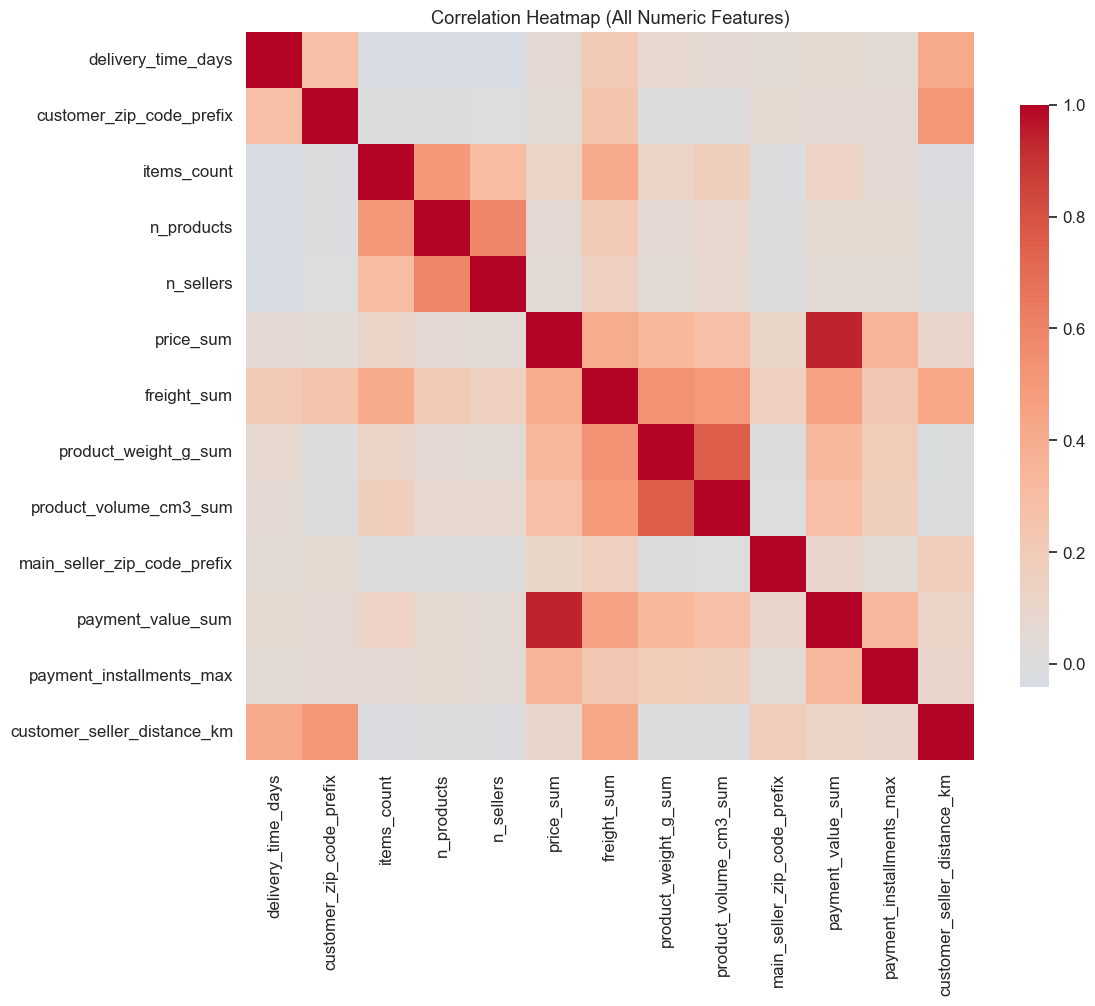


 Feature pairs with correlation above 0.8 (possible multicollinearity):


,Feature_1,Feature_2,Correlation
54,price_sum,payment_value_sum,0.941704


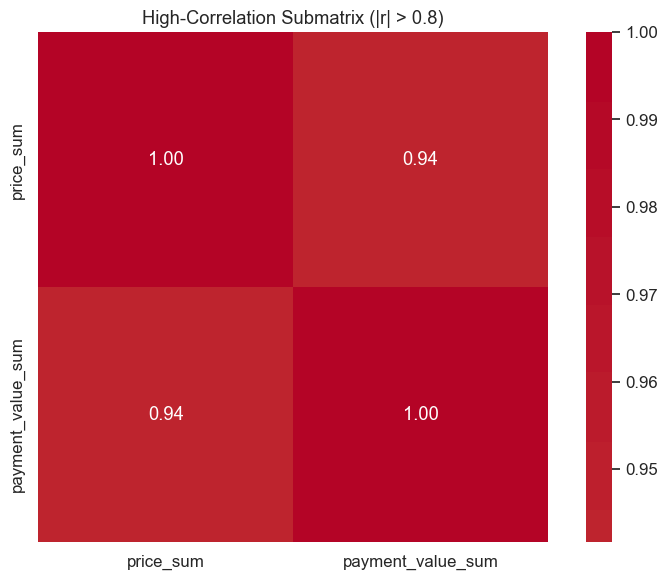

In [14]:
# Correlation Map & Multicollinearity Check
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sns.set(style="whitegrid", font_scale=1.1)

# Read clean dataset
df = pd.read_csv("clean_outputs/final_train_clean.csv", low_memory=False)
print(df.shape)

# Keep only numeric columns (exclude IDs and categorical variables)
num_df = df.select_dtypes(include=[np.number])
print(f"Number of numeric columns: {num_df.shape[1]}")

# Compute correlation matrix
corr = num_df.corr()

# Visualize full correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    annot=False,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap (All Numeric Features)")
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (multicollinearity threshold = 0.8)
threshold = 0.8
threshold = 0.8
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)
high_corr = corr_pairs[abs(corr_pairs["Correlation"]) > threshold].sort_values(
    by="Correlation", ascending=False
)
print(f"\n Feature pairs with correlation above {threshold} (possible multicollinearity):")
display(high_corr.head(20))

# Visualize high-correlation submatrix (if many features are correlated)
if len(high_corr) > 0:
    high_features = list(set(high_corr["Feature_1"]).union(set(high_corr["Feature_2"])))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr.loc[high_features, high_features],
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0, square=True
    )
    plt.title("High-Correlation Submatrix (|r| > 0.8)")
    plt.tight_layout()
    plt.show()
else:
    print("No strong correlations detected (|r| > 0.8)")

We use visualization to check and select our potential features and target. Based on Box-plot and histagram, it is obvious that all of plotting features are highly right-skewed with lots of outliers, especially for ```product_weight_g_sum``` and ```product_volume_cm3_sum```. It's normal for e-commerce because sometimes customers would like to purchase very large or heavy products, such as furniture or home appliances. Also, the distribution of our target is also highly right-skewed, meaning lots of products delivered in short periods. In addition, we plot the Corrleation with Delivery time and Corrleation Heatmap to check potential multicollinearity. According to the heatmap, ```price_sum``` and ```payment_value_sum``` may have multicollinearity as the correlation is higher than our threshold (0.8).





In [16]:
# VIF: Variance Inflation Factor for Multicollinearity
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) Select numeric features, excluding target and obvious ID columns
X = df.select_dtypes(include=[np.number]).copy()
for col in ["delivery_time_days", "order_id", "customer_id"]:
    if col in X.columns:
        X.drop(columns=[col], inplace=True, errors="ignore")

# 2) Drop constant or all-null columns, and remove duplicate columns
n_before = X.shape[1]
X = X.loc[:, X.std(numeric_only=True) > 0]  # remove constant columns (std = 0)
X = X.T.drop_duplicates().T                 # remove duplicate columns
print(f"Preprocessing: numeric features {n_before} → {X.shape[1]} columns (removed constants & duplicates)")

# 3) Handle missing values: fill with median (does not modify original df)
X = X.fillna(X.median(numeric_only=True))

def compute_vif_frame(Xmat: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame of VIF values for each column"""
    vif_vals = []
    cols = list(Xmat.columns)
    for i in range(len(cols)):
        vif_vals.append(variance_inflation_factor(Xmat.values, i))
    out = pd.DataFrame({"feature": cols, "VIF": vif_vals}).sort_values("VIF", ascending=False)
    return out.reset_index(drop=True)

# 4) Iteratively remove features with highest VIF above the threshold
VIF_THRESHOLD = 10.0
X_iter = X.copy()
removed = []

print("\n Starting iterative removal of high-VIF features (threshold > {:.1f})".format(VIF_THRESHOLD))
round_idx = 0
while True:
    round_idx += 1
    vif_df = compute_vif_frame(X_iter)
    max_vif = vif_df["VIF"].iloc[0]
    max_feat = vif_df["feature"].iloc[0]
    print(f"[Round {round_idx}] Highest VIF: {max_vif:.2f}  ← {max_feat}")

    if max_vif > VIF_THRESHOLD:
        # Remove this feature and continue
        X_iter = X_iter.drop(columns=[max_feat])
        removed.append((max_feat, max_vif))
    else:
        print("All remaining features have VIF <= threshold. Stopping iteration.")
        break

# 5) Output summary results
print("\n Removed high-VIF features (in order):")
if removed:
    for feat, vifv in removed:
        print(f" - {feat}: VIF={vifv:.2f}")
else:
    print("（None）")

final_vif = compute_vif_frame(X_iter)
print("\n Final number of retained features:", X_iter.shape[1])
display(final_vif)

Preprocessing: numeric features 12 → 12 columns (removed constants & duplicates)

 Starting iterative removal of high-VIF features (threshold > 10.0)
[Round 1] Highest VIF: 47.81  ← n_products
[Round 2] Highest VIF: 15.15  ← price_sum
[Round 3] Highest VIF: 12.19  ← n_sellers
[Round 4] Highest VIF: 8.30  ← freight_sum
All remaining features have VIF <= threshold. Stopping iteration.

 Removed high-VIF features (in order):
 - n_products: VIF=47.81
 - price_sum: VIF=15.15
 - n_sellers: VIF=12.19

 Final number of retained features: 9


,feature,VIF
0,freight_sum,8.303389
1,items_count,4.571385
2,product_volume_cm3_sum,3.760943
3,customer_seller_distance_km,3.722473
4,product_weight_g_sum,3.691829
5,customer_zip_code_prefix,3.035578
6,payment_installments_max,2.351239
7,payment_value_sum,2.162026
8,main_seller_zip_code_prefix,1.785218


To select features for our business problem, we use VIF to further screening for multicollinearity. We delete ```n_products```, ```price_sum``` and ```n_sellers``` as VIF values are higher than 10. The remaining features are chosen for feature engineering and prediction.







In [18]:
# Simple Linear regression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("clean_outputs/final_train_clean.csv")

FEATURES_BASE = [
    'freight_sum',
    'items_count',
    'product_volume_cm3_sum',
    'product_weight_g_sum',
    'customer_seller_distance_km',
    'payment_installments_max',
    'payment_value_sum'
]
TARGET = 'delivery_time_days'

X_trail = df[FEATURES_BASE]
y_trail = df[TARGET]
# Define model
model_lr = LinearRegression()

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model_lr, X_trail, y_trail, cv=kf)

#  Model evaluation
mae = mean_absolute_error(y_trail, y_pred_cv)
rmse = np.sqrt(mean_squared_error(y_trail, y_pred_cv))
r2 = r2_score(y_trail, y_pred_cv)

print("Simple Linear Regression (5-Fold CV)")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


Simple Linear Regression (5-Fold CV)
MAE : 5.4870
RMSE: 8.1205
R²  : 0.1822


Before feature Engineering, we attempted to use a simple model to understand the situation.

# **3. Feature Engineering**

In [21]:
# Logistics Time Efficiency Feature Engineering

import pandas as pd
import numpy as np
import os

# 1) Load data
TRAIN_PATH = 'clean_outputs/final_train_clean.csv'
TEST_PATH  = 'clean_outputs/final_test_clean.csv'

OUT_TRAIN = 'clean_outputs/final_train_enriched.csv'
OUT_TEST  = 'clean_outputs/final_test_enriched.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Standardize product category column name (handle different naming conventions)
if 'main_product_category_name_en' in train.columns:
    cat_col = 'main_product_category_name_en'
else:
    cat_col = 'main_product_category_name_english' if 'main_product_category_name_english' in train.columns else None

# Target column
TARGET = 'delivery_time_days'
assert TARGET in train.columns, f"Target column missing in training data: {TARGET}"

# 2) Utility function: smoothed target mean encoding (fit on train only)
def mean_encode(train_df, test_df, key_col, target_col, m=50, min_count=1, suffix=None):
    """
    Perform target mean encoding for key_col using smoothing:
    smooth_mean = (count * mean + m * global_mean) / (count + m)
    Statistics are computed from train_df only, then mapped to both train/test.
    """
    global_mean = train_df[target_col].mean()
    grp = train_df.groupby(key_col)[target_col].agg(['mean', 'count']).reset_index()
    grp['smooth'] = (grp['mean'] * grp['count'] + m * global_mean) / (grp['count'] + m)
    grp.loc[grp['count'] < min_count, 'smooth'] = global_mean

    new_col = f"{key_col}_mean_delivery" if suffix is None else suffix
    mapper = grp.set_index(key_col)['smooth']

    train_df[new_col] = train_df[key_col].map(mapper).fillna(global_mean)
    test_df[new_col]  = test_df[key_col].map(mapper).fillna(global_mean)
    return new_col

# 4) Cross-state
if 'customer_state' in train.columns and 'main_seller_state' in train.columns:
    train['is_cross_state'] = (train['customer_state'] != train['main_seller_state']).astype(int)
    test['is_cross_state']  = (test['customer_state'] != test['main_seller_state']).astype(int)
else:
    train['is_cross_state'] = 0
    test['is_cross_state'] = 0

# 5) Target mean encoding: State / City / Category (fit on train, map to both)
new_cols = []

if 'customer_state' in train.columns:
    new_cols.append(mean_encode(train, test, 'customer_state', TARGET, m=30,
                                suffix='customer_state_mean_delivery'))

if 'main_seller_state' in train.columns:
    new_cols.append(mean_encode(train, test, 'main_seller_state', TARGET, m=30,
                                suffix='seller_state_mean_delivery'))

# City-level data is more sparse, so use a higher smoothing factor (m)
if 'customer_city' in train.columns:
    new_cols.append(mean_encode(train, test, 'customer_city', TARGET, m=120,
                                suffix='customer_city_mean_delivery'))

if 'main_seller_city' in train.columns:
    new_cols.append(mean_encode(train, test, 'main_seller_city', TARGET, m=120,
                                suffix='seller_city_mean_delivery'))

# Product category
if cat_col is not None and cat_col in train.columns:
    new_cols.append(mean_encode(train, test, cat_col, TARGET, m=50,
                                suffix='category_mean_delivery'))

# Finalize & export
os.makedirs('clean_outputs', exist_ok=True)
train.to_csv(OUT_TRAIN, index=False)
test.to_csv(OUT_TEST, index=False)

print("  - Cross-state flag: is_cross_state")
print("  - Mean-encoded features:", new_cols)
print(f"Saved: {OUT_TRAIN}")
print(f"Saved: {OUT_TEST}")
train.info()

  - Cross-state flag: is_cross_state
  - Mean-encoded features: ['customer_state_mean_delivery', 'seller_state_mean_delivery', 'customer_city_mean_delivery', 'seller_city_mean_delivery', 'category_mean_delivery']
Saved: clean_outputs/final_train_enriched.csv
Saved: clean_outputs/final_test_enriched.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76085 entries, 0 to 76084
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       76085 non-null  object 
 1   customer_id                    76085 non-null  object 
 2   order_status                   76085 non-null  object 
 3   order_purchase_timestamp       76085 non-null  object 
 4   order_approved_at              76075 non-null  object 
 5   order_delivered_carrier_date   76085 non-null  object 
 6   order_delivered_customer_date  76085 non-null  object 
 7   order_estimated_delivery_date  76085 non-n

To generate features for the delivery time prediction task, we apply target mean encoding based on customer and seller locations as well as product categories. We compute smoothed averages of delivery days within the training set to capture regional and product-level shipping patterns, then map these encoded values to both train and test data for modeling.

In [23]:
import pandas as pd
import numpy as np
import os


TRAIN_PATH = "clean_outputs/final_train_enriched.csv"
TEST_PATH  = "clean_outputs/final_test_enriched.csv"

OUT_TRAIN_PATH = "clean_outputs/final_train_log_y.csv"
OUT_TEST_PATH  = "clean_outputs/final_test_log.csv"

os.makedirs("clean_outputs", exist_ok=True)

# Load data
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")

# Features to be log-transformed
log_features = [
    "freight_sum",
    "product_weight_g_sum",
    "product_volume_cm3_sum",
    "payment_value_sum",
    "payment_installments_max",
    "customer_seller_distance_km"
]

# Apply log1p transformation to both train & test
for df_name, df in zip(["Train", "Test"], [train, test]):
    for col in log_features:
        if col in df.columns:
            new_col = f"log_{col}"
            df[new_col] = np.log1p(df[col])
    print(f"{df_name} log-transformed features added: {len(log_features)} columns")

# Save new files
train.to_csv(OUT_TRAIN_PATH, index=False, encoding="utf-8-sig")
test.to_csv(OUT_TEST_PATH, index=False, encoding="utf-8-sig")

print(f"\n New files saved:")
print(f"Train -> {OUT_TRAIN_PATH}")
print(f"Test  -> {OUT_TEST_PATH}")

Train shape: (76085, 35)
Test shape : (18998, 35)
Train log-transformed features added: 6 columns
Test log-transformed features added: 6 columns

 New files saved:
Train -> clean_outputs/final_train_log_y.csv
Test  -> clean_outputs/final_test_log.csv


Based on the visualization of features, we use log1p to alter the skewness without change outliers.

In [25]:
# Selecting features for modelling

import os
TRAIN_PATH = 'clean_outputs/final_train_log_y.csv'
os.makedirs('clean_outputs', exist_ok=True)

# Load data
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

TARGET = 'delivery_time_days'

# 1) Original 7 base features
FEATURES_BASE = [
    'log_freight_sum',
    'items_count',
    'log_product_volume_cm3_sum',
    'log_product_weight_g_sum',
    'log_customer_seller_distance_km',
    'log_payment_installments_max',
    'log_payment_value_sum'
]

# 2) Additional candidate features
CAND_NEW = [
    'is_cross_state',
    'customer_state_mean_delivery',
    'seller_state_mean_delivery',
    'customer_city_mean_delivery',
    'seller_city_mean_delivery',
    'category_mean_delivery'
]

FEATURES = FEATURES_BASE + [c for c in CAND_NEW if c in train.columns]

# **4. Model Building**

## Linear regression (Baseline model)

In [28]:
# Linear regression
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

X = train[FEATURES]
y = train[TARGET]

# Define the model
model = LinearRegression()

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store MAEs for each fold
fold_mae = []

# Loop through each fold to compute fold-specific MAE
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred_val)
    fold_mae.append(mae)
    print(f"Fold {fold_idx} MAE: {mae:.4f}")

# Compute overall predictions using cross_val_predict for consistency
y_pred_cv = cross_val_predict(model, X, y, cv=kf)

# Evaluation (overall)
mae_lr = mean_absolute_error(y, y_pred_cv)
rmse_lr = np.sqrt(mean_squared_error(y, y_pred_cv))
r2_lr = r2_score(y, y_pred_cv)

print("\nLinear Regression (5-Fold CV) Results:")
print(f"Average MAE : {mae_lr:.4f}")
print(f"RMSE        : {rmse_lr:.4f}")
print(f"R²          : {r2_lr:.4f}")

Fold 1 MAE: 5.1400
Fold 2 MAE: 5.1619
Fold 3 MAE: 5.1534
Fold 4 MAE: 5.0952
Fold 5 MAE: 5.1424

Linear Regression (5-Fold CV) Results:
Average MAE : 5.1386
RMSE        : 7.7239
R²          : 0.2601


## Lasso Regression

In [30]:
# Lasso Regression without Hyperparameter selection
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

X = train[FEATURES]
y = train[TARGET]

# Define model
model = Lasso(alpha=1.0, random_state=42)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y, cv=kf)

# Evaluation
mae = mean_absolute_error(y, y_pred_cv)
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
r2 = r2_score(y, y_pred_cv)

print("Lasso Regression (Feature Engineering, no tuning)")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

Lasso Regression (Feature Engineering, no tuning)
MAE : 5.2277
RMSE: 7.8118
R²  : 0.2432


In [31]:
# Lasso with Hyperparameter Selection
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

X = train[FEATURES]
y = train[TARGET]

# Define the model
# Use LassoCV to automatically find the best alpha (L1 regularization)
model = LassoCV(cv=5, random_state=42, n_jobs=-1)

# Cross-validation prediction
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y, cv=kf)

# Evaluation
mae_ls = mean_absolute_error(y, y_pred_cv)
rmse_ls = np.sqrt(mean_squared_error(y, y_pred_cv))
r2_ls = r2_score(y, y_pred_cv)

print("Lasso Regression (5-Fold CV) Results:")
print(f"MAE : {mae_ls:.4f}")
print(f"RMSE: {rmse_ls:.4f}")
print(f"R²  : {r2_ls:.4f}")

Lasso Regression (5-Fold CV) Results:
MAE : 5.1389
RMSE: 7.7245
R²  : 0.2600


##  LightGBM

[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1868
[LightGBM] [Info] Number of data points in the train set: 60868, number of used features: 13
[LightGBM] [Info] Start training from score 12.476064
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Info] Auto-choosing col-wise multi-thread

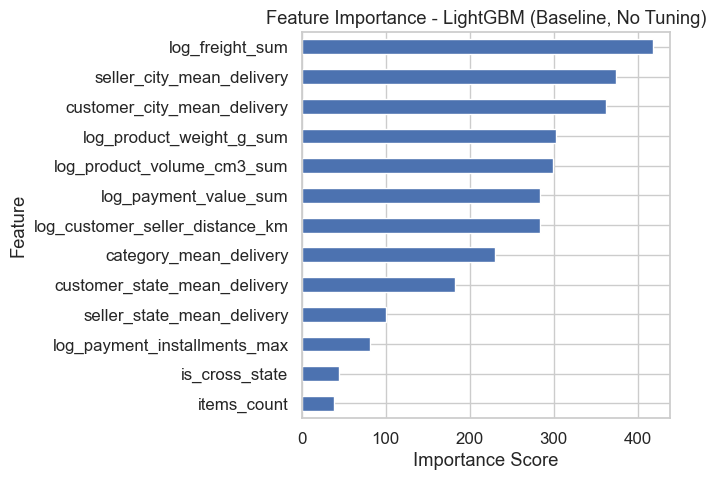

In [33]:
# LightGBM without Hyperparameter selection
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import random
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

X = train[FEATURES]
y = train[TARGET]

# Define model
# Default parameters, no tuning
model_lgb = lgb.LGBMRegressor(
    random_state=SEED,
    n_jobs=-1,
    subsample=1.0,
    colsample_bytree=1.0,
    bagging_freq=0
)

# Cross-validation prediction
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model_lgb, X, y, cv=kf)

# Evaluation
mae = mean_absolute_error(y, y_pred_cv)
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
r2 = r2_score(y, y_pred_cv)

print("LightGBM Baseline (5-Fold CV, no tuning)")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# Feature importance
model_lgb.fit(X, y)
importances = pd.Series(model_lgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

# Visualization
plt.figure(figsize=(7,5))
importances.plot(kind='barh')
plt.title("Feature Importance - LightGBM (Baseline, No Tuning)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

[I 2025-11-07 00:01:04,350] A new study created in memory with name: no-name-c3f12419-8147-439f-89e4-f9c3272673f5


  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1868
[LightGBM] [Info] Number of data points in the train set: 60868, number of used features: 13
[LightGBM] [Info] Start training from score 12.476064
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

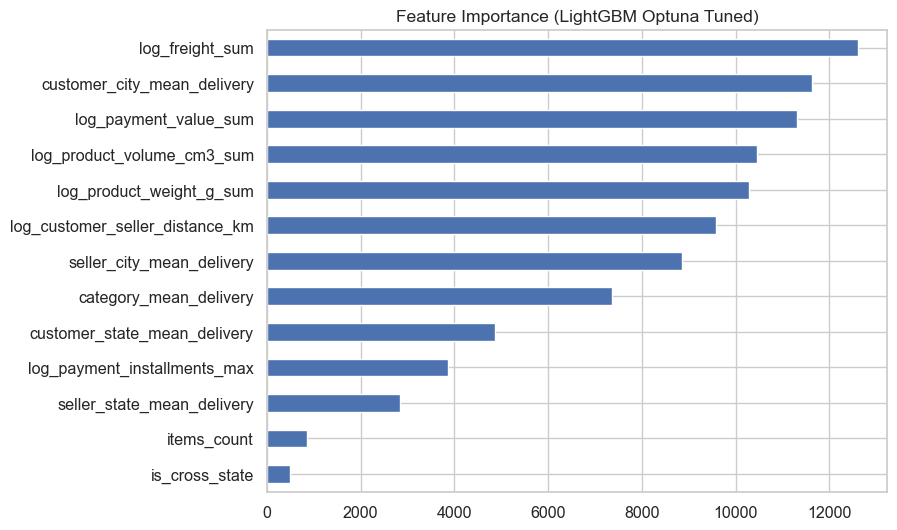

In [34]:
# LightGBM with Hyperparameter selection
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import random

sns.set(style="whitegrid", font_scale=1.05)

# Fix all random seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
X = train[FEATURES]
y = train[TARGET]

# Define the Optuna objective function
def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "random_state": SEED,
        "n_jobs": -1
    }

    model = lgb.LGBMRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    rmse_scores = []
    for train_idx, valid_idx in kf.split(X):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(
          X_train, y_train,
          eval_set=[(X_valid, y_valid)],
          eval_metric="rmse",
          callbacks=[lgb.log_evaluation(0)]
        )
        preds = model.predict(X_valid)
        rmse = np.sqrt(mean_squared_error(y_valid, preds))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

# Run Optuna optimization (trials = 5)
# Fix Optuna sampling randomness
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\nBest Parameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

# Retrain using best parameters + 5-Fold CV evaluation
best_params = study.best_params.copy()
best_params.update({
    "objective": "regression",
    "n_estimators": 1000,
    "random_state": 42,
    "n_jobs": -1
})

model_opt = lgb.LGBMRegressor(**best_params)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_true_all, y_pred_all = [], []
for train_idx, valid_idx in kf.split(X):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    model_opt.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[lgb.log_evaluation(0)]
    )
    preds = model_opt.predict(X_valid)
    y_true_all.extend(y_valid)
    y_pred_all.extend(preds)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

mae_lgb = mean_absolute_error(y_true_all, y_pred_all)
rmse_lgb = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
r2_lgb = r2_score(y_true_all, y_pred_all)

print("\nLightGBM Optuna Tuning + 5-Fold CV Results:")
print(f"MAE : {mae_lgb:.4f}")
print(f"RMSE: {rmse_lgb:.4f}")
print(f"R²  : {r2_lgb:.4f}")

# Feature Importance
model_opt.fit(X, y)
importance = pd.Series(model_opt.feature_importances_, index=FEATURES).sort_values(ascending=True)
# Visualization
plt.figure(figsize=(8,6))
importance.plot(kind="barh")
plt.title("Feature Importance (LightGBM Optuna Tuned)")
plt.show()

## XGBoost

XGBoost Baseline (5-Fold CV, No Tuning)
MAE : 4.9485
RMSE: 7.5422
R²  : 0.2945


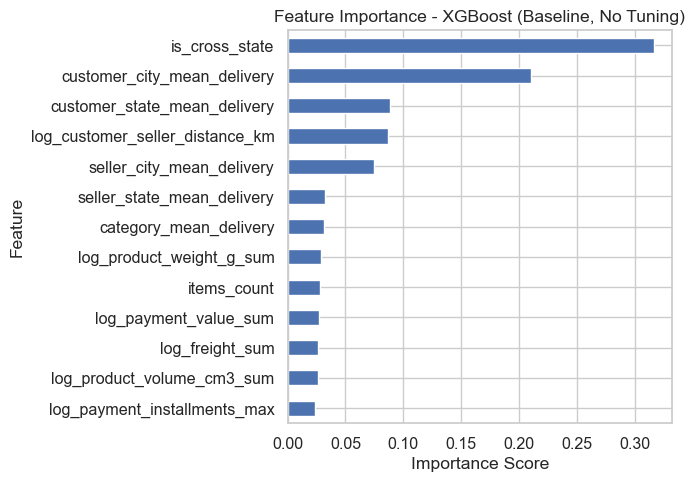

In [36]:
# XGBoost without Hyperparameter selection
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os
import random

# Fix all randomness
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


X = train[FEATURES]
y = train[TARGET]

# Define model
# Default hyperparameters (no tuning)
model_xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=SEED,
    n_jobs=-1,
    subsample=1.0,
    colsample_bytree=1.0
)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model_xgb, X, y, cv=kf)

# Evaluation
mae = mean_absolute_error(y, y_pred_cv)
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
r2 = r2_score(y, y_pred_cv)

print("XGBoost Baseline (5-Fold CV, No Tuning)")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# Feature importance
model_xgb.fit(X, y)
importances = pd.Series(model_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

# Visualization
plt.figure(figsize=(7,5))
importances.plot(kind='barh')
plt.title("Feature Importance - XGBoost (Baseline, No Tuning)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


[I 2025-11-07 00:03:34,912] A new study created in memory with name: no-name-41d80ee5-f3b9-4616-847f-9435ea393037


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 00:04:04,547] Trial 0 finished with value: 7.50140713150327 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2.4041677639819286, 'gamma': 0.15599452033620265, 'reg_alpha': 0.11616722433639892, 'reg_lambda': 1.7323522915498704}. Best is trial 0 with value: 7.50140713150327.
[I 2025-11-07 00:04:22,253] Trial 1 finished with value: 7.616661279394038 and parameters: {'learning_rate': 0.06054365855469246, 'max_depth': 8, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 8.491983767203795, 'gamma': 0.21233911067827616, 'reg_alpha': 0.36364993441420124, 'reg_lambda': 0.36680901970686763}. Best is trial 0 with value: 7.50140713150327.
[I 2025-11-07 00:04:35,971] Trial 2 finished with value: 7.425802039039756 and parameters: {'learning_rate': 0.024878734419814436, 'max_depth': 7, 'subsample': 0.7727780074568463, 'colsample_by

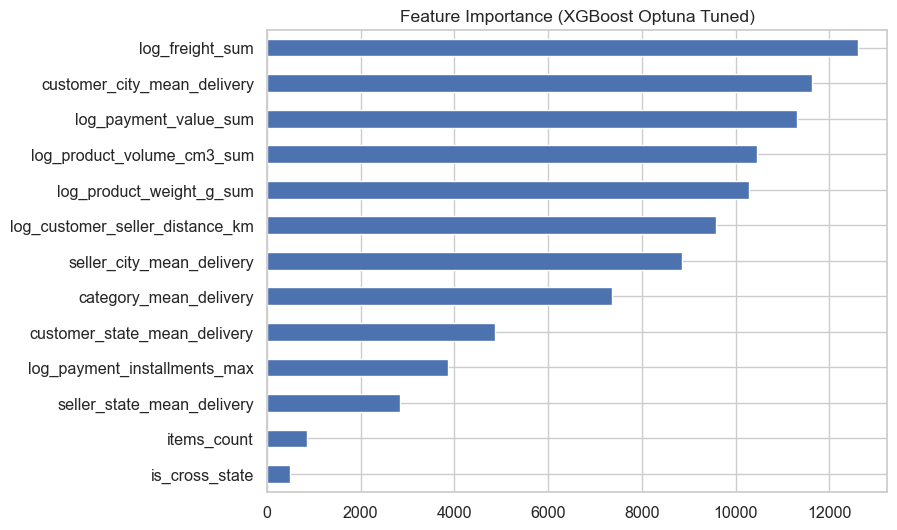

In [37]:
# XGBoost with Hyperparameter selection
import os
import random
import pandas as pd
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_predict,cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
import matplotlib.pyplot as plt
import seaborn as sns

# Fix all randomness
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

sns.set(style="whitegrid", font_scale=1.05)
X = train[FEATURES]
y = train[TARGET]
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 1),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 2),
        "random_state": SEED,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Use RMSE as the optimization metric (the smaller, the better)
    preds = cross_val_predict(model, X, y, cv=kf)
    rmse = np.sqrt(mean_squared_error(y, preds))
    return rmse

# Run Optuna Optimization (trials = 5)
# Fix Optuna randomness
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\nBest Parameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

# Train with Best Parameters + Cross-Validation Evaluation
best_params = study.best_params.copy()
best_params.update({
    "objective": "reg:squarederror",
    "n_estimators": 1000,
    "random_state": 42,
    "n_jobs": -1
})

model_opt = XGBRegressor(**best_params)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model_opt, X, y, cv=kf)

mae_scores = cross_val_score(model_opt, X, y, cv=kf, scoring='neg_mean_absolute_error')

positive_mae_scores = -mae_scores

print("\n--- MAE for Each Fold (XGBoost Tuned) ---")
for i, mae_score in enumerate(positive_mae_scores):
    print(f"Fold {i+1} MAE: {mae_score:.4f}")
print("----------------------------------------")

# Compute Evaluation Metrics
mae_xgb = mean_absolute_error(y, y_pred_cv)
rmse_xgb = np.sqrt(mean_squared_error(y, y_pred_cv))
r2_xgb = r2_score(y, y_pred_cv)

print("\nXGBoost Optuna Tuning + 5-Fold CV Results:")
print(f"MAE : {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²  : {r2_xgb:.4f}")

# Visualization
plt.figure(figsize=(8,6))
importance.plot(kind='barh')
plt.title("Feature Importance (XGBoost Optuna Tuned)")
plt.show()

## Random Forest

Random Forest Baseline (5-Fold CV, No Tuning)
MAE : 5.3384
RMSE: 7.9863
R²  : 0.2090


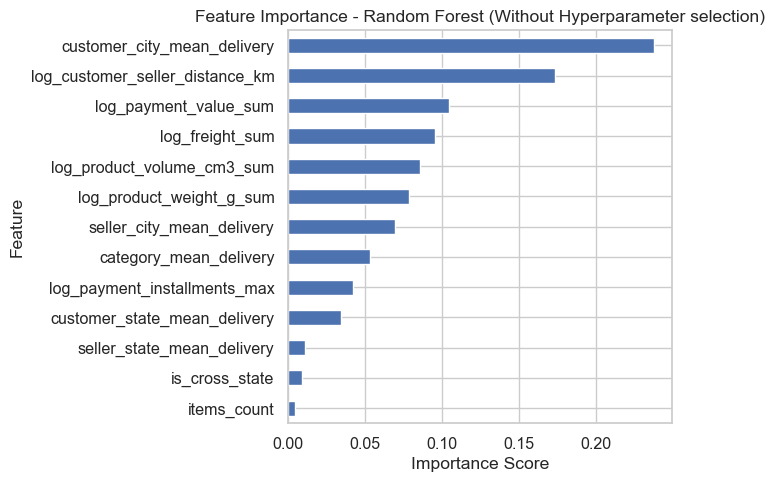

In [39]:
# Random Forest without Hyperparameter selection
import os
import random
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Fix all randomness
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

X = train[FEATURES]
y = train[TARGET]

# Define model
model_rf = RandomForestRegressor(
    n_estimators=10,
    random_state=SEED,
    n_jobs=-1,
    bootstrap=True,
    oob_score=False
)

# Cross-validation prediction
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model_rf, X, y, cv=kf)

# Evaluate model
mae = mean_absolute_error(y, y_pred_cv)
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
r2 = r2_score(y, y_pred_cv)

print("Random Forest Baseline (5-Fold CV, No Tuning)")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# Feature importance
model_rf.fit(X, y)
importances = pd.Series(model_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

# Visualization
plt.figure(figsize=(7,5))
importances.plot(kind='barh')
plt.title("Feature Importance - Random Forest (Without Hyperparameter selection)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

[I 2025-11-07 00:06:03,526] A new study created in memory with name: no-name-6d8b15bc-85cd-4d8e-91d3-5299d23f2eeb


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 00:06:22,717] Trial 0 finished with value: 7.464547127077077 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 7.464547127077077.
[I 2025-11-07 00:06:42,798] Trial 1 finished with value: 7.498901336554708 and parameters: {'n_estimators': 220, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 7.464547127077077.
[I 2025-11-07 00:06:56,085] Trial 2 finished with value: 7.530577879723706 and parameters: {'n_estimators': 161, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 7.464547127077077.
[I 2025-11-07 00:07:09,915] Trial 3 finished with value: 7.486603352709958 and parameters: {'n_estimators': 191, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 

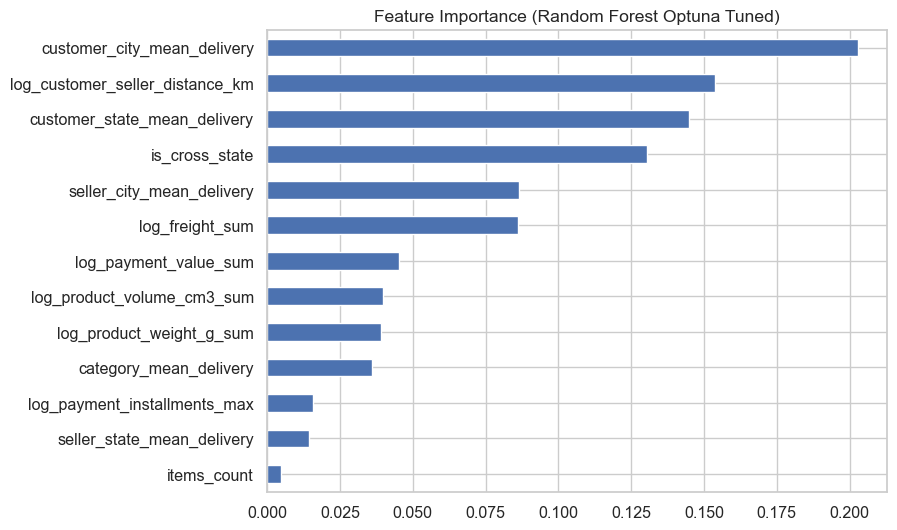

In [40]:
# Random Forest with Hyperparameter selection
import os
import random
import pandas as pd
import numpy as np
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid", font_scale=1.05)

# Fix all randomness
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

X = train[FEATURES]
y = train[TARGET]
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": SEED,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    rmse_scores = []
    for train_idx, valid_idx in kf.split(X):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_valid)
        rmse = np.sqrt(mean_squared_error(y_valid, preds))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

# Run Optuna Optimization (5 trials)
# Fix Optuna randomness
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\nBest Parameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

# Retrain Using Best Parameters + 5-Fold CV Evaluation
best_params = study.best_params.copy()
best_params.update({"random_state": 42, "n_jobs": -1})
model_best = RandomForestRegressor(**best_params)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_true_all, y_pred_all = [], []

for train_idx, valid_idx in kf.split(X):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model_best.fit(X_train, y_train)
    preds = model_best.predict(X_valid)
    y_true_all.extend(y_valid)
    y_pred_all.extend(preds)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

mae_rf = mean_absolute_error(y_true_all, y_pred_all)
rmse_rf = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
r2_rf = r2_score(y_true_all, y_pred_all)

print("\nRandom Forest (Optuna Tuning + 5-Fold CV) Results:")
print(f"MAE : {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²  : {r2_rf:.4f}")

# Feature Importance
model_best.fit(X, y)
importance = pd.Series(model_best.feature_importances_, index=FEATURES).sort_values(ascending=True)

# Visualization
plt.figure(figsize=(8,6))
importance.plot(kind="barh")
plt.title("Feature Importance (Random Forest Optuna Tuned)")
plt.show()

After comparsion, we choose XGBoost as our best single model. Although sometimes the metrics is not performing as the best one, XGBoost is more stable compared to LightGBM. Taking computation cost as our consideration, Random Forest has large computaion cost. Linear and Lasso regression perform relatively poor.

# **5. Further Feature Engineering and EDA**

Data loaded successfully: train=(76085, 41), test=(18998, 41)
Saved train file: clean_outputs/final_train_log_y_full_v2.csv
Saved test file : clean_outputs/final_test_transformed_full_v2.csv


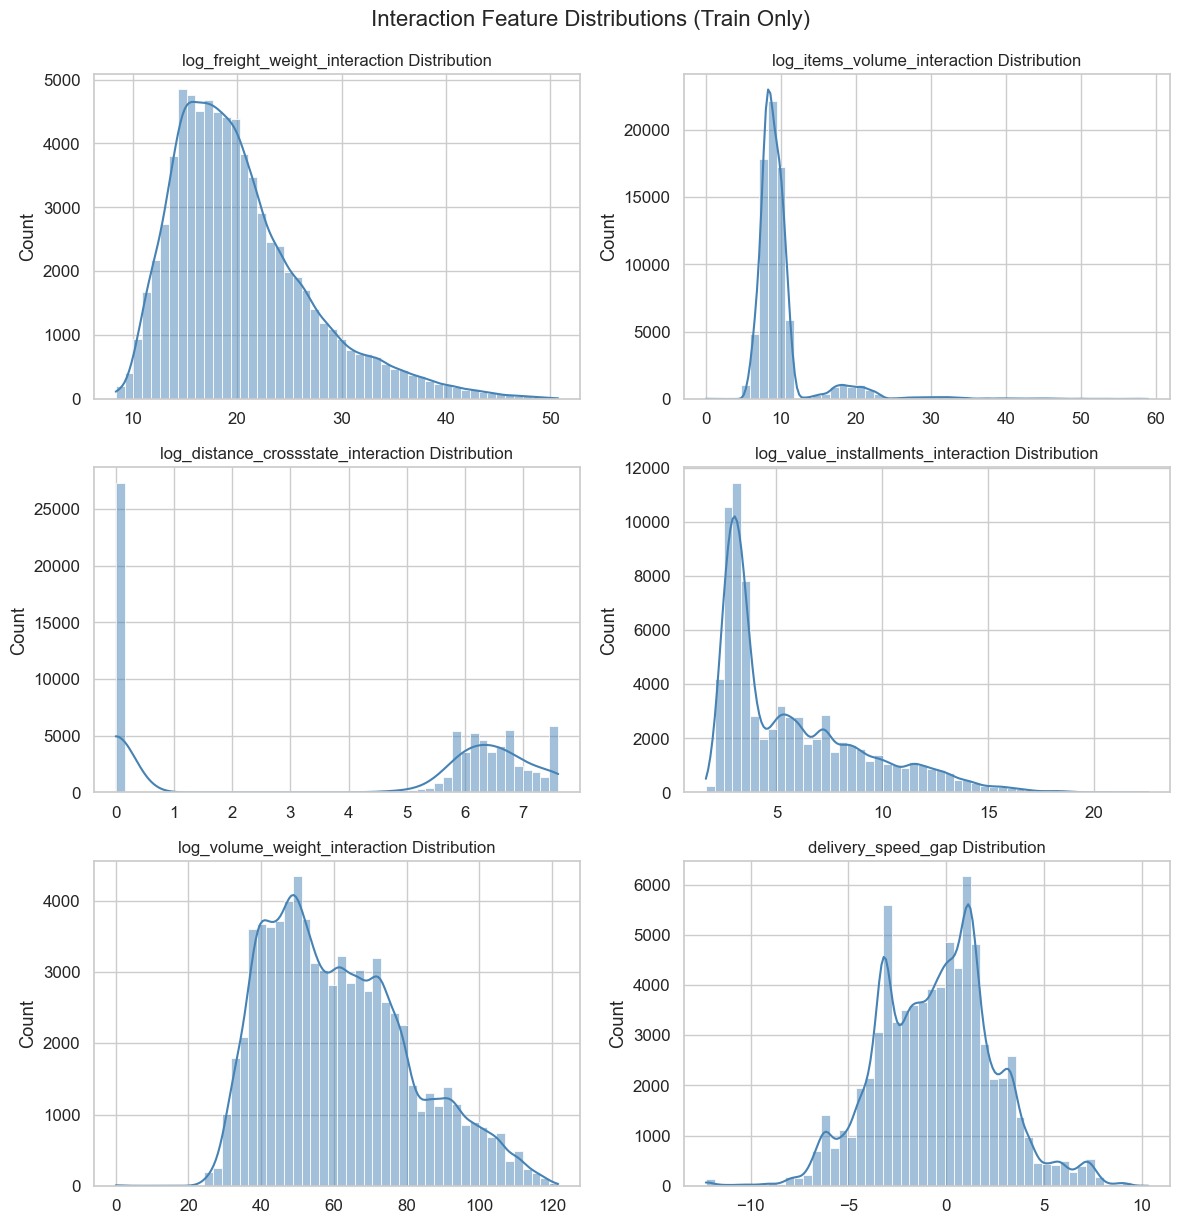

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# Paths
TRAIN_PATH = "clean_outputs/final_train_log_y.csv"     # already has log features
TEST_PATH  = "clean_outputs/final_test_log.csv"        # raw test, needs log features

FINAL_TRAIN = "clean_outputs/final_train_log_y_full_v2.csv"
FINAL_TEST  = "clean_outputs/final_test_transformed_full_v2.csv"

os.makedirs("clean_outputs", exist_ok=True)

# Step 1: Load data
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
print(f"Data loaded successfully: train={train.shape}, test={test.shape}")

# Step 2: Add log features for test only
LOG_COLS = [
    "freight_sum",
    "product_weight_g_sum",
    "product_volume_cm3_sum",
    "payment_value_sum",
    "payment_installments_max",
    "customer_seller_distance_km"
]

for col in LOG_COLS:
    test[f"log_{col}"] = np.log1p(test[col])

# Step 3: Define function to add interaction and gap features
def add_interactions(df):
    df["log_freight_weight_interaction"] = df["log_freight_sum"] * df["log_product_weight_g_sum"]
    df["log_items_volume_interaction"] = df["items_count"] * df["log_product_volume_cm3_sum"]
    df["log_distance_crossstate_interaction"] = df["log_customer_seller_distance_km"] * df["is_cross_state"]
    df["log_value_installments_interaction"] = df["log_payment_value_sum"] * df["log_payment_installments_max"]
    df["log_volume_weight_interaction"] = df["log_product_volume_cm3_sum"] * df["log_product_weight_g_sum"]
    df["delivery_speed_gap"] = df["customer_city_mean_delivery"] - df["seller_city_mean_delivery"]
    return df

# Step 4: Add interactions
train = add_interactions(train)
test  = add_interactions(test)

# Step 5: Log-transform target (train only)
if "delivery_time_days" not in train.columns:
    raise KeyError("Missing target column: delivery_time_days")
train["log_delivery_time_days"] = np.log1p(train["delivery_time_days"])

# Step 6: Save processed datasets
train.to_csv(FINAL_TRAIN, index=False)
test.to_csv(FINAL_TEST, index=False)
print(f"Saved train file: {FINAL_TRAIN}")
print(f"Saved test file : {FINAL_TEST}")

# Step 7: Plot histograms for train (interaction features only)
interaction_cols = [
    "log_freight_weight_interaction",
    "log_items_volume_interaction",
    "log_distance_crossstate_interaction",
    "log_value_installments_interaction",
    "log_volume_weight_interaction",
    "delivery_speed_gap"
]

n_cols = 2
n_rows = int(np.ceil(len(interaction_cols) / n_cols))
plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(interaction_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=train, x=col, bins=50, kde=True, color='steelblue')
    plt.title(f"{col} Distribution", fontsize=12)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()
plt.suptitle("Interaction Feature Distributions (Train Only)", fontsize=16, y=1.02)
plt.show()


We add further feature engineering for prediction, including add log features in test data and interaction features in both train and test data. Then, we plot these interaction features. ```log_items_volume_interaction```is highly right-skewed and redundant with its base features, potentially introducing noise, so it was removed. ```log_value_installments_interaction``` has similar issue, and it was removed as well. ```log_distance_crossstate_interaction``` is zero-inflated and redundant with base features, likely to introduce noise, and we remove it.









In [45]:
import pandas as pd
import numpy as np
import os

# Paths
TRAIN_PATH = "clean_outputs/final_train_log_y_full_v2.csv"
TEST_PATH  = "clean_outputs/final_test_transformed_full_v2.csv"

OUT_TRAIN = "clean_outputs/final_train_transformed_cleaned.csv"
OUT_TEST  = "clean_outputs/final_test_transformed_cleaned.csv"

os.makedirs("clean_outputs", exist_ok=True)

# Load data
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
print(f"Loaded: train={train.shape}, test={test.shape}")

# Clip delivery_speed_gap (train only)
train["delivery_speed_gap"] = train["delivery_speed_gap"].clip(lower=-10, upper=10)

# Drop selected interaction columns (train only)
DROP_COLS = [
    "log_distance_crossstate_interaction",
    "log_items_volume_interaction",
    "log_value_installments_interaction"
]

train.drop(columns=[c for c in DROP_COLS if c in train.columns], inplace=True)

# Log-transform target (train only)
if "delivery_time_days" in train.columns:
    train["log_delivery_time_days"] = np.log1p(train["delivery_time_days"])

# Save cleaned datasets
train.to_csv(OUT_TRAIN, index=False)
test.to_csv(OUT_TEST, index=False)

print("Saved cleaned train file:", OUT_TRAIN)
print("Saved cleaned test file :", OUT_TEST)


Loaded: train=(76085, 48), test=(18998, 47)
Saved cleaned train file: clean_outputs/final_train_transformed_cleaned.csv
Saved cleaned test file : clean_outputs/final_test_transformed_cleaned.csv


In [46]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
IN_PATH  = Path("clean_outputs/final_test_transformed_cleaned.csv")
OUT_PATH = Path("clean_outputs/final_test_transformed_with_log_y.csv")

# Load the dataset
test = pd.read_csv(IN_PATH)
print(f"Data loaded successfully: {test.shape}")

# Check if target column exists
if 'delivery_time_days' not in test.columns:
    raise KeyError("Column 'delivery_time_days' not found in the dataset. Cannot apply log transform.")

# Apply log1p transformation
test['log_delivery_time_days'] = np.log1p(test['delivery_time_days'])

# Save the new dataset
test.to_csv(OUT_PATH, index=False)
print(f"New file saved successfully: {OUT_PATH}")
print("Added new column: 'log_delivery_time_days' (computed as log(1 + delivery_time_days))")
print(test[['delivery_time_days', 'log_delivery_time_days']].head())


Data loaded successfully: (18998, 47)
New file saved successfully: clean_outputs\final_test_transformed_with_log_y.csv
Added new column: 'log_delivery_time_days' (computed as log(1 + delivery_time_days))
   delivery_time_days  log_delivery_time_days
0           27.025660                3.333121
1            5.022477                1.795499
2            7.207674                2.105070
3           12.207488                2.580784
4            8.120556                2.210531


We dropped these exceptional variables, and take log to target.

# **6. Using stacking model and applying test data**

In [49]:
# Stacking Model – Base: XGBoost (Optuna Tuned), Meta: Linear Regression
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import os
import random

# File paths (according to your convention)
TRAIN_PATH = "clean_outputs/final_train_transformed_cleaned.csv"          # Training data (contains log_delivery_time_days)
TEST_PRED_PATH = "clean_outputs/final_test_transformed_cleaned.csv"       # Test set (features only, for inference)
TEST_EVAL_PATH = "clean_outputs/final_test_transformed_with_log_y.csv"    # Test set with labels (for offline evaluation)
OUTPUT_PRED_PATH = "clean_outputs/test_predictions_original_scale.csv"

# Load datasets
df_train = pd.read_csv(TRAIN_PATH)
df_test_pred = pd.read_csv(TEST_PRED_PATH)
df_test_eval = pd.read_csv(TEST_EVAL_PATH)

# Feature definitions
ALL_CANDIDATES = [
    'log_freight_sum','items_count','log_product_volume_cm3_sum','log_product_weight_g_sum',
    'log_customer_seller_distance_km','log_payment_installments_max','log_payment_value_sum',
    "log_freight_weight_interaction","log_volume_weight_interaction","delivery_speed_gap",
    'is_cross_state','customer_state_mean_delivery','seller_state_mean_delivery',
    'customer_city_mean_delivery','seller_city_mean_delivery','category_mean_delivery'
]
FEATURES = [c for c in ALL_CANDIDATES if c in df_train.columns]
TARGET = 'log_delivery_time_days'

# Fix all randomness
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Select features and target
X = df_train[FEATURES].apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(df_train[TARGET], errors='coerce').fillna(0)

# Optuna hyperparameter tuning for XGBoost
def objective(trial):
    """Objective function for Optuna — minimize CV RMSE."""
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 3.0),
        "random_state": SEED,
        "n_jobs": -1
    }

    # Base model (XGB)
    base_model = XGBRegressor(**params)
    # Meta model (Linear Regression)
    meta_model = LinearRegression()

    # Create stacking model with 5-Fold CV
    stack_model = StackingRegressor(
        estimators=[("gbt", base_model)],
        final_estimator=meta_model,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1, passthrough=False
    )

    # Perform 5-Fold CV manually to compute mean RMSE
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []
    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        stack_model.fit(X_tr, y_tr)
        pred_va = stack_model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred_va))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

# Run and Fix Optuna randomness
print("Starting Optuna optimization...")
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\nOptuna tuning complete.")
print("Best parameters found:", study.best_params)
print("Best mean CV RMSE:", study.best_value)

# Retrain final stacking model with best parameters
best_params = study.best_params
base_estimator = XGBRegressor(**best_params)
meta_model = LinearRegression()
final_stack = StackingRegressor(
    estimators=[("gbt", base_estimator)],
    final_estimator=meta_model,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, passthrough=False
)

final_stack.fit(X, y)
print("\nFinal stacking model retrained using best Optuna parameters.")
# === Training-set evaluation (in-sample) ===
train_pred_log  = final_stack.predict(X)
train_pred_days = np.expm1(train_pred_log)

rmse_log_tr = np.sqrt(mean_squared_error(y, train_pred_log))
mae_log_tr  = mean_absolute_error(y, train_pred_log)
r2_log_tr   = r2_score(y, train_pred_log)

print("\nTraining set evaluation (Log-space):")
print(f"RMSE = {rmse_log_tr:.4f}  MAE = {mae_log_tr:.4f}  R² = {r2_log_tr:.4f}")

y_train_days = np.expm1(y)
rmse_days_tr = np.sqrt(mean_squared_error(y_train_days, train_pred_days))
mae_days_tr  = mean_absolute_error(y_train_days, train_pred_days)
r2_days_tr   = r2_score(y_train_days, train_pred_days)

print("\nTraining set evaluation (Original scale - days):")
print(f"RMSE = {rmse_days_tr:.4f}  MAE = {mae_days_tr:.4f}  R² = {r2_days_tr:.4f}")

[I 2025-11-07 00:07:54,930] A new study created in memory with name: no-name-3f0eb9b9-3373-4f9c-ad39-79bcb75d7211


Starting Optuna optimization...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 00:08:50,138] Trial 0 finished with value: 0.4546627921604462 and parameters: {'n_estimators': 350, 'learning_rate': 0.1785436060870726, 'max_depth': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.8899863008405067}. Best is trial 0 with value: 0.4546627921604462.
[I 2025-11-07 00:09:21,198] Trial 1 finished with value: 0.4462613373986999 and parameters: {'n_estimators': 223, 'learning_rate': 0.146962368105409, 'max_depth': 7, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'reg_lambda': 2.9247746304049858}. Best is trial 1 with value: 0.4462613373986999.
[I 2025-11-07 00:09:53,290] Trial 2 finished with value: 0.4513683485683977 and parameters: {'n_estimators': 533, 'learning_rate': 0.03261137469244295, 'max_depth': 4, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'reg_lambda': 1.8118910790805947}. Best is trial 1 with value: 0.4462613373986999.
[I 2025-11-07 00:10:29,313] Tria

In [50]:
# XGBoost + LightGBM Stacking (meta = LinearRegression)
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
import os
import random

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

TRAIN_PATH = "clean_outputs/final_train_transformed_cleaned.csv"
TEST_PRED_PATH = "clean_outputs/final_test_transformed_cleaned.csv"
TEST_EVAL_PATH = "clean_outputs/final_test_transformed_with_log_y.csv"
OUTPUT_PRED_PATH = "clean_outputs/test_predictions_original_scale.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test_pred = pd.read_csv(TEST_PRED_PATH)
df_test_eval = pd.read_csv(TEST_EVAL_PATH)

ALL_CANDIDATES = [
    'log_freight_sum','items_count','log_product_volume_cm3_sum','log_product_weight_g_sum',
    'log_customer_seller_distance_km','log_payment_installments_max','log_payment_value_sum',
    "log_freight_weight_interaction","log_volume_weight_interaction","delivery_speed_gap",
    'is_cross_state','customer_state_mean_delivery','seller_state_mean_delivery',
    'customer_city_mean_delivery','seller_city_mean_delivery','category_mean_delivery'
]
FEATURES = [c for c in ALL_CANDIDATES if c in df_train.columns]
TARGET = 'log_delivery_time_days'

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

X = df_train[FEATURES].apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(df_train[TARGET], errors='coerce').fillna(0)

def objective(trial):
    # XGB params
    xgb_params = {
        "n_estimators": trial.suggest_int("xgb_n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("xgb_learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("xgb_max_depth", 3, 10),
        "subsample": trial.suggest_float("xgb_subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("xgb_reg_lambda", 0.5, 3.0),
        "min_child_weight": trial.suggest_float("xgb_min_child_weight", 1.0, 10.0),
        "random_state": SEED,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    # LGB params
    lgb_params = {
        "n_estimators": trial.suggest_int("lgb_n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("lgb_learning_rate", 0.02, 0.2, log=True),
        "num_leaves": trial.suggest_int("lgb_num_leaves", 15, 63),
        "max_depth": trial.suggest_int("lgb_max_depth", -1, 12),
        "subsample": trial.suggest_float("lgb_subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("lgb_colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("lgb_reg_lambda", 0.5, 3.0),
        "random_state": SEED,
        "n_jobs": -1
    }

    # Base learners
    xgb = XGBRegressor(**xgb_params)
    lgb = LGBMRegressor(**lgb_params)
    # Meta learner: LinearRegression (no tuning)
    meta = LinearRegression()

    stack = StackingRegressor(
        estimators=[("xgb", xgb), ("lgb", lgb)],
        final_estimator=meta,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
        n_jobs=-1,
        passthrough=False
    )

    # 5-fold CV on training set (log-space target)
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        stack.fit(X_tr, y_tr)
        pred = stack.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, pred)))
    return float(np.mean(rmses))

print("Starting Optuna optimization for XGB + LGB stacking (Linear meta)...")
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\nOptuna tuning complete.")
print("Best parameters found:")
print(study.best_params)
print("Best mean CV RMSE:", study.best_value)

bp = study.best_params

xgb_best = XGBRegressor(
    n_estimators=bp["xgb_n_estimators"],
    learning_rate=bp["xgb_learning_rate"],
    max_depth=bp["xgb_max_depth"],
    subsample=bp["xgb_subsample"],
    colsample_bytree=bp["xgb_colsample_bytree"],
    reg_lambda=bp["xgb_reg_lambda"],
    min_child_weight=bp["xgb_min_child_weight"],
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)

lgb_best = LGBMRegressor(
    n_estimators=bp["lgb_n_estimators"],
    learning_rate=bp["lgb_learning_rate"],
    num_leaves=bp["lgb_num_leaves"],
    max_depth=bp["lgb_max_depth"],
    subsample=bp["lgb_subsample"],
    colsample_bytree=bp["lgb_colsample_bytree"],
    reg_lambda=bp["lgb_reg_lambda"],
    random_state=SEED,
    n_jobs=-1
)

# Meta learner: LinearRegression (no tuning)
meta_best = LinearRegression()

final_stack = StackingRegressor(
    estimators=[("xgb", xgb_best), ("lgb", lgb_best)],
    final_estimator=meta_best,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
    passthrough=False
)

final_stack.fit(X, y)
print("\nFinal stacking model (XGB + LGB, meta=Linear) retrained with best params.")

# === Training-set evaluation (in-sample) ===
train_pred_log  = final_stack.predict(X)
train_pred_days = np.expm1(train_pred_log)

rmse_log_tr = np.sqrt(mean_squared_error(y, train_pred_log))
mae_log_tr  = mean_absolute_error(y, train_pred_log)
r2_log_tr   = r2_score(y, train_pred_log)

print("\nTraining set evaluation (Log-space):")
print(f"RMSE = {rmse_log_tr:.4f}  MAE = {mae_log_tr:.4f}  R² = {r2_log_tr:.4f}")

y_train_days = np.expm1(y)
rmse_days_tr = np.sqrt(mean_squared_error(y_train_days, train_pred_days))
mae_days_tr  = mean_absolute_error(y_train_days, train_pred_days)
r2_days_tr   = r2_score(y_train_days, train_pred_days)

print("\nTraining set evaluation (Original scale - days):")
print(f"RMSE = {rmse_days_tr:.4f}  MAE = {mae_days_tr:.4f}  R² = {r2_days_tr:.4f}")

[I 2025-11-07 00:11:03,284] A new study created in memory with name: no-name-2b4e5506-cfcd-4ea2-9e18-dc79b9a6eeec


Starting Optuna optimization for XGB + LGB stacking (Linear meta)...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 00:13:05,114] Trial 0 finished with value: 0.44418287270322027 and parameters: {'xgb_n_estimators': 487, 'xgb_learning_rate': 0.1785436060870726, 'xgb_max_depth': 8, 'xgb_subsample': 0.8394633936788146, 'xgb_colsample_bytree': 0.6624074561769746, 'xgb_reg_lambda': 0.8899863008405067, 'xgb_min_child_weight': 1.5227525095137953, 'lgb_n_estimators': 733, 'lgb_learning_rate': 0.0798261175712336, 'lgb_num_leaves': 49, 'lgb_max_depth': -1, 'lgb_subsample': 0.9879639408647978, 'lgb_colsample_bytree': 0.9329770563201687, 'lgb_reg_lambda': 1.0308477766956905}. Best is trial 0 with value: 0.44418287270322027.
[I 2025-11-07 00:13:54,145] Trial 1 finished with value: 0.4499286069654934 and parameters: {'xgb_n_estimators': 391, 'xgb_learning_rate': 0.03050945891610522, 'xgb_max_depth': 5, 'xgb_subsample': 0.8099025726528951, 'xgb_colsample_bytree': 0.7727780074568463, 'xgb_reg_lambda': 1.2280728504951048, 'xgb_min_child_weight': 6.506676052501415, 'lgb_n_estimators': 369, 'lgb_learnin

In [52]:
# XGBoost + LightGBM Stacking (meta = LightGBM)
import numpy as np
import pandas as pd
import optuna
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.ensemble import StackingRegressor
import os
import random

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

TRAIN_PATH = "clean_outputs/final_train_transformed_cleaned.csv"
TEST_PRED_PATH = "clean_outputs/final_test_transformed_cleaned.csv"
TEST_EVAL_PATH = "clean_outputs/final_test_transformed_with_log_y.csv"
OUTPUT_PRED_PATH = "clean_outputs/test_predictions_original_scale.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test_pred = pd.read_csv(TEST_PRED_PATH)
df_test_eval = pd.read_csv(TEST_EVAL_PATH)

ALL_CANDIDATES = [
    'log_freight_sum','items_count','log_product_volume_cm3_sum','log_product_weight_g_sum',
    'log_customer_seller_distance_km','log_payment_installments_max','log_payment_value_sum',
    "log_freight_weight_interaction","log_volume_weight_interaction","delivery_speed_gap",
    'is_cross_state','customer_state_mean_delivery','seller_state_mean_delivery',
    'customer_city_mean_delivery','seller_city_mean_delivery','category_mean_delivery'
]
FEATURES = [c for c in ALL_CANDIDATES if c in df_train.columns]
TARGET = 'log_delivery_time_days'

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

X = df_train[FEATURES].apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(df_train[TARGET], errors='coerce').fillna(0)

def objective(trial):
    xgb_params = {
        "n_estimators": trial.suggest_int("xgb_n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("xgb_learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("xgb_max_depth", 3, 10),
        "subsample": trial.suggest_float("xgb_subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("xgb_reg_lambda", 0.5, 3.0),
        "min_child_weight": trial.suggest_float("xgb_min_child_weight", 1.0, 10.0),
        "random_state": SEED,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    lgb_params = {
        "n_estimators": trial.suggest_int("lgb_n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("lgb_learning_rate", 0.02, 0.2, log=True),
        "num_leaves": trial.suggest_int("lgb_num_leaves", 15, 63),
        "max_depth": trial.suggest_int("lgb_max_depth", -1, 12),
        "subsample": trial.suggest_float("lgb_subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("lgb_colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("lgb_reg_lambda", 0.5, 3.0),
        "random_state": SEED,
        "n_jobs": -1
    }

    meta_params = {
        "n_estimators": trial.suggest_int("meta_n_estimators", 100, 400),
        "learning_rate": trial.suggest_float("meta_learning_rate", 0.02, 0.2, log=True),
        "num_leaves": trial.suggest_int("meta_num_leaves", 15, 63),
        "max_depth": trial.suggest_int("meta_max_depth", -1, 10),
        "reg_lambda": trial.suggest_float("meta_reg_lambda", 0.5, 3.0),
        "random_state": SEED,
        "n_jobs": -1
    }

    xgb = XGBRegressor(**xgb_params)
    lgb = LGBMRegressor(**lgb_params)
    meta = LGBMRegressor(**meta_params)

    stack = StackingRegressor(
        estimators=[("xgb", xgb), ("lgb", lgb)],
        final_estimator=meta,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
        n_jobs=-1,
        passthrough=False
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        stack.fit(X_tr, y_tr)
        pred = stack.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, pred)))
    return float(np.mean(rmses))

print("Starting Optuna optimization for XGB + LGB stacking...")
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\nOptuna tuning complete.")
print("Best parameters found:")
print(study.best_params)
print("Best mean CV RMSE:", study.best_value)

bp = study.best_params

xgb_best = XGBRegressor(
    n_estimators=bp["xgb_n_estimators"],
    learning_rate=bp["xgb_learning_rate"],
    max_depth=bp["xgb_max_depth"],
    subsample=bp["xgb_subsample"],
    colsample_bytree=bp["xgb_colsample_bytree"],
    reg_lambda=bp["xgb_reg_lambda"],
    min_child_weight=bp["xgb_min_child_weight"],
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)

lgb_best = LGBMRegressor(
    n_estimators=bp["lgb_n_estimators"],
    learning_rate=bp["lgb_learning_rate"],
    num_leaves=bp["lgb_num_leaves"],
    max_depth=bp["lgb_max_depth"],
    subsample=bp["lgb_subsample"],
    colsample_bytree=bp["lgb_colsample_bytree"],
    reg_lambda=bp["lgb_reg_lambda"],
    random_state=SEED,
    n_jobs=-1
)

meta_best = LGBMRegressor(
    n_estimators=bp["meta_n_estimators"],
    learning_rate=bp["meta_learning_rate"],
    num_leaves=bp["meta_num_leaves"],
    max_depth=bp["meta_max_depth"],
    reg_lambda=bp["meta_reg_lambda"],
    random_state=SEED,
    n_jobs=-1
)

final_stack = StackingRegressor(
    estimators=[("xgb", xgb_best), ("lgb", lgb_best)],
    final_estimator=meta_best,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
    passthrough=False
)

print("\nStarting 5-Fold Cross-Validation with Best Parameters...")

def mae_days_scorer(y_log, y_pred_log):
    y_true_days = np.expm1(y_log)
    y_pred_days = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_days, y_pred_days)

days_mae_scorer = make_scorer(mae_days_scorer, greater_is_better=False)

cv_kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

mae_scores_days = cross_val_score(
    final_stack,
    X,
    y,
    cv=cv_kf,
    scoring=days_mae_scorer,
    n_jobs=-1
)

positive_mae_scores_days = -mae_scores_days

print("\nMAE for Each Fold (Stacking Model, Original scale - days)")
for i, mae_score in enumerate(positive_mae_scores_days):
    print(f"Fold {i+1} MAE (days): {mae_score:.4f}")
print("--------------------------------------------------------------")

oof_predictions_log = cross_val_predict(
    final_stack,
    X,
    y,
    cv=cv_kf,
    n_jobs=-1
)

y_train_days_cv = np.expm1(y)
oof_predictions_days_cv = np.expm1(oof_predictions_log)

cv_mae_days = mean_absolute_error(y_train_days_cv, oof_predictions_days_cv)
cv_rmse_days = np.sqrt(mean_squared_error(y_train_days_cv, oof_predictions_days_cv))
cv_r2_days = r2_score(y_train_days_cv, oof_predictions_days_cv)

print("\nOverall 5-Fold CV Results (Original scale - days):")
print(f"CV MAE : {cv_mae_days:.4f}")
print(f"CV RMSE: {cv_rmse_days:.4f}")
print(f"CV R²  : {cv_r2_days:.4f}")

final_stack.fit(X, y)
print("\nFinal stacking model (XGB + LGB, meta=LGB) retrained with best params.")

# === Training-set evaluation (in-sample) ===
train_pred_log  = final_stack.predict(X)
train_pred_days = np.expm1(train_pred_log)

rmse_log_tr = np.sqrt(mean_squared_error(y, train_pred_log))
mae_log_tr  = mean_absolute_error(y, train_pred_log)
r2_log_tr   = r2_score(y, train_pred_log)

print("\nTraining set evaluation (Log-space):")
print(f"RMSE = {rmse_log_tr:.4f}  MAE = {mae_log_tr:.4f}  R² = {r2_log_tr:.4f}")

y_train_days = np.expm1(y)
rmse_days_tr = np.sqrt(mean_squared_error(y_train_days, train_pred_days))
mae_days_tr  = mean_absolute_error(y_train_days, train_pred_days)
r2_days_tr   = r2_score(y_train_days, train_pred_days)

print("\nTraining set evaluation (Original scale - days):")
print(f"RMSE = {rmse_days_tr:.4f}  MAE = {mae_days_tr:.4f}  R² = {r2_days_tr:.4f}")

# === Predictions for the labeled test set (df_test_eval) ===
# Use only features that exist in df_test_eval to be safe
eval_feature_cols = [c for c in FEATURES if c in df_test_eval.columns]
X_eval = df_test_eval[eval_feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Predict in log space and convert back to days
eval_pred_log = final_stack.predict(X_eval)
eval_pred_days = np.expm1(eval_pred_log)

# Log-space
if 'log_delivery_time_days' in df_test_eval.columns:
    y_test_log = pd.to_numeric(df_test_eval['log_delivery_time_days'], errors='coerce').fillna(0)
    rmse_log = np.sqrt(mean_squared_error(y_test_log, eval_pred_log))
    mae_log  = mean_absolute_error(y_test_log, eval_pred_log)
    r2_log   = r2_score(y_test_log, eval_pred_log)
    print("\nEvaluation on labeled test set (Log-space):")
    print(f"RMSE = {rmse_log:.4f}  MAE = {mae_log:.4f}  R² = {r2_log:.4f}")

# Original-scale
if 'delivery_time_days' in df_test_eval.columns:
    y_test_days = pd.to_numeric(df_test_eval['delivery_time_days'], errors='coerce').fillna(0)
    rmse_days = np.sqrt(mean_squared_error(y_test_days, eval_pred_days))
    mae_days  = mean_absolute_error(y_test_days, eval_pred_days)
    r2_days   = r2_score(y_test_days, eval_pred_days)
    print("\nEvaluation on labeled test set (Original scale - days):")
    print(f"RMSE = {rmse_days:.4f}  MAE = {mae_days:.4f}  R² = {r2_days:.4f}")


[I 2025-11-07 09:20:35,933] A new study created in memory with name: no-name-86e493b8-7e33-44f7-860e-1ae85551bd2a


Starting Optuna optimization for XGB + LGB stacking...


  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 60868, number of used features: 2
[LightGBM] [Info] Start training from score 2.419957
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

After implementing more feature, we select XGBoost+LightGBM and using LightGBM as our Meta model.

# **7. Model Evaluation**

In [54]:
# === Linear Regression: predict on labeled test set and save residuals ===
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------- paths (from your project) ----------
TRAIN_PATH     = "clean_outputs/final_train_transformed_cleaned.csv"
TEST_EVAL_PATH = "clean_outputs/final_test_transformed_with_log_y.csv"
OUT_CSV        = "clean_outputs/linear_test_eval_predictions_vs_truth.csv"

# ---------- load ----------
df_train     = pd.read_csv(TRAIN_PATH)
df_test_eval = pd.read_csv(TEST_EVAL_PATH)

# ---------- features / target ----------
ALL_CANDIDATES = [
    'log_freight_sum','items_count','log_product_volume_cm3_sum',
    'log_product_weight_g_sum','log_customer_seller_distance_km',
    'log_payment_installments_max','log_payment_value_sum'
]
TARGET = 'log_delivery_time_days'

FEATURES = [c for c in ALL_CANDIDATES if c in df_train.columns and c in df_test_eval.columns]
if not FEATURES:
    raise ValueError("No overlapping FEATURES between train and test_eval.")

to_num = lambda df: df.apply(pd.to_numeric, errors="coerce").fillna(0)

X_train = to_num(df_train[FEATURES])
y_train = pd.to_numeric(df_train[TARGET], errors="coerce").fillna(0)

X_test  = to_num(df_test_eval[FEATURES])
y_test_log = pd.to_numeric(df_test_eval[TARGET], errors="coerce").fillna(0)

# train & predict
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_test_log = lr.predict(X_test)

y_pred_days = np.expm1(y_pred_test_log)
y_true_days = np.expm1(y_test_log)

# metrics on original scale
mae_lr  = mean_absolute_error(y_true_days, y_pred_days)
rmse_lr = np.sqrt(mean_squared_error(y_true_days, y_pred_days))
r2_lr = r2_score(y_true_days, y_pred_days)
print("Linear Regression on Test (original scale):")
print(f"MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

# build residual dataframe & save
out_df = pd.DataFrame({
    "y_true_days": y_true_days,
    "y_pred_days": y_pred_days,
    "residual_days": y_true_days - y_pred_days,
    "y_true_log": y_test_log,
    "y_pred_log": y_pred_test_log,
    "residual_log": y_test_log - y_pred_test_log
})

for key in ["order_id", "order_item_id", "customer_id"]:
    if key in df_test_eval.columns:
        out_df[key] = df_test_eval[key].values

out_df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print(f"Saved predictions vs truth with residuals to: {OUT_CSV}")


Linear Regression on Test (original scale):
MAE=5.3384  RMSE=7.9863  R²=0.2090
Saved predictions vs truth with residuals to: clean_outputs/linear_test_eval_predictions_vs_truth.csv


[I 2025-11-07 09:33:19,758] A new study created in memory with name: no-name-29b16e1e-042e-41ef-bc13-03e166b89a33


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 09:33:33,801] Trial 0 finished with value: 0.44420796782820604 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2.4041677639819286, 'gamma': 0.15599452033620265, 'reg_alpha': 0.11616722433639892, 'reg_lambda': 1.7323522915498704}. Best is trial 0 with value: 0.44420796782820604.
[I 2025-11-07 09:33:55,399] Trial 1 finished with value: 0.44989063150727837 and parameters: {'learning_rate': 0.06054365855469246, 'max_depth': 8, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 8.491983767203795, 'gamma': 0.21233911067827616, 'reg_alpha': 0.36364993441420124, 'reg_lambda': 0.36680901970686763}. Best is trial 0 with value: 0.44420796782820604.
[I 2025-11-07 09:34:13,940] Trial 2 finished with value: 0.44358905227520967 and parameters: {'learning_rate': 0.024878734419814436, 'max_depth': 7, 'subsample': 0.7727780074568463, 

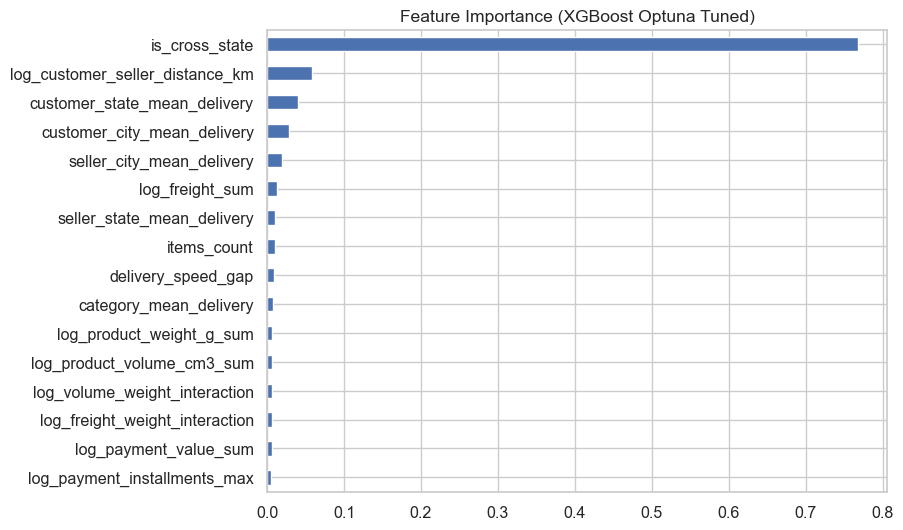

In [56]:
# === XGBoost with Hyperparameter selection + Test Evaluation ===
import os
import random
import pandas as pd
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

TRAIN_PATH = "clean_outputs/final_train_transformed_cleaned.csv"
TEST_PRED_PATH = "clean_outputs/final_test_transformed_cleaned.csv"
TEST_EVAL_PATH = "clean_outputs/final_test_transformed_with_log_y.csv"
OUTPUT_PRED_PATH = "clean_outputs/test_predictions_original_scale.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test_pred = pd.read_csv(TEST_PRED_PATH)
df_test_eval = pd.read_csv(TEST_EVAL_PATH)

ALL_CANDIDATES = [
    'log_freight_sum','items_count','log_product_volume_cm3_sum','log_product_weight_g_sum',
    'log_customer_seller_distance_km','log_payment_installments_max','log_payment_value_sum',
    "log_freight_weight_interaction","log_volume_weight_interaction","delivery_speed_gap",
    'is_cross_state','customer_state_mean_delivery','seller_state_mean_delivery',
    'customer_city_mean_delivery','seller_city_mean_delivery','category_mean_delivery'
]
FEATURES = [c for c in ALL_CANDIDATES if c in df_train.columns]
TARGET = 'log_delivery_time_days'

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

sns.set(style="whitegrid", font_scale=1.05)

# Define Optuna objective

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test_pred[FEATURES]
y_test_log = df_test_eval[TARGET]

# Define Optuna objective
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 1),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 2),
        "random_state": SEED,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    preds = cross_val_predict(model, X_train, y_train, cv=kf)
    rmse = np.sqrt(mean_squared_error(y_train, preds))
    return rmse

# Run Optuna optimization
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\nBest Parameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

# Refit using best parameters + cross-validation
best_params = study.best_params.copy()
best_params.update({
    "objective": "reg:squarederror",
    "n_estimators": 1000,
    "random_state": SEED,
    "n_jobs": -1
})

model_opt = XGBRegressor(**best_params)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model_opt, X_train, y_train, cv=kf)

# CV performance
mae_cv = mean_absolute_error(y_train, y_pred_cv)
rmse_cv = np.sqrt(mean_squared_error(y_train, y_pred_cv))
r2_cv = r2_score(y_train, y_pred_cv)

print("\nXGBoost Optuna Tuned (Cross-Validation)")
print(f"MAE (CV) : {mae_cv:.4f}")
print(f"RMSE(CV) : {rmse_cv:.4f}")
print(f"R²  (CV) : {r2_cv:.4f}")

# Fit full model and predict test set
model_opt.fit(X_train, y_train)
y_pred_test_log = model_opt.predict(X_test)

# Convert back to original scale if log-transformed
y_pred_test = np.expm1(y_pred_test_log)
y_test = np.expm1(y_test_log)

# Test set performance
mae_test_xgb = mean_absolute_error(y_test, y_pred_test)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test_xgb = r2_score(y_test, y_pred_test)

print("\nXGBoost Optuna Tuned (Test Set)- Original Scale")
print(f"MAE  (Test): {mae_test_xgb:.4f}")
print(f"RMSE (Test): {rmse_test_xgb:.4f}")
print(f"R²   (Test): {r2_test_xgb:.4f}")

# Feature importance
importance = pd.Series(model_opt.feature_importances_, index=FEATURES)
plt.figure(figsize=(8,6))
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (XGBoost Optuna Tuned)")
plt.show()

In [58]:
# XGBoost + LightGBM Stacking (meta = LightGBM)
import numpy as np
import pandas as pd
import optuna
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.ensemble import StackingRegressor
import os
import random

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

TRAIN_PATH = "clean_outputs/final_train_transformed_cleaned.csv"
TEST_PRED_PATH = "clean_outputs/final_test_transformed_cleaned.csv"
TEST_EVAL_PATH = "clean_outputs/final_test_transformed_with_log_y.csv"
OUTPUT_PRED_PATH = "clean_outputs/test_predictions_original_scale.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test_pred = pd.read_csv(TEST_PRED_PATH)
df_test_eval = pd.read_csv(TEST_EVAL_PATH)

ALL_CANDIDATES = [
    'log_freight_sum','items_count','log_product_volume_cm3_sum','log_product_weight_g_sum',
    'log_customer_seller_distance_km','log_payment_installments_max','log_payment_value_sum',
    "log_freight_weight_interaction","log_volume_weight_interaction","delivery_speed_gap",
    'is_cross_state','customer_state_mean_delivery','seller_state_mean_delivery',
    'customer_city_mean_delivery','seller_city_mean_delivery','category_mean_delivery'
]
FEATURES = [c for c in ALL_CANDIDATES if c in df_train.columns]
TARGET = 'log_delivery_time_days'

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

X = df_train[FEATURES].apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(df_train[TARGET], errors='coerce').fillna(0)

def objective(trial):
    xgb_params = {
        "n_estimators": trial.suggest_int("xgb_n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("xgb_learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("xgb_max_depth", 3, 10),
        "subsample": trial.suggest_float("xgb_subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("xgb_reg_lambda", 0.5, 3.0),
        "min_child_weight": trial.suggest_float("xgb_min_child_weight", 1.0, 10.0),
        "random_state": SEED,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    lgb_params = {
        "n_estimators": trial.suggest_int("lgb_n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("lgb_learning_rate", 0.02, 0.2, log=True),
        "num_leaves": trial.suggest_int("lgb_num_leaves", 15, 63),
        "max_depth": trial.suggest_int("lgb_max_depth", -1, 12),
        "subsample": trial.suggest_float("lgb_subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("lgb_colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("lgb_reg_lambda", 0.5, 3.0),
        "random_state": SEED,
        "n_jobs": -1
    }

    meta_params = {
        "n_estimators": trial.suggest_int("meta_n_estimators", 100, 400),
        "learning_rate": trial.suggest_float("meta_learning_rate", 0.02, 0.2, log=True),
        "num_leaves": trial.suggest_int("meta_num_leaves", 15, 63),
        "max_depth": trial.suggest_int("meta_max_depth", -1, 10),
        "reg_lambda": trial.suggest_float("meta_reg_lambda", 0.5, 3.0),
        "random_state": SEED,
        "n_jobs": -1
    }

    xgb = XGBRegressor(**xgb_params)
    lgb = LGBMRegressor(**lgb_params)
    meta = LGBMRegressor(**meta_params)

    stack = StackingRegressor(
        estimators=[("xgb", xgb), ("lgb", lgb)],
        final_estimator=meta,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
        n_jobs=-1,
        passthrough=False
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        stack.fit(X_tr, y_tr)
        pred = stack.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, pred)))
    return float(np.mean(rmses))

print("Starting Optuna optimization for XGB + LGB stacking...")
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\nOptuna tuning complete.")
print("Best parameters found:")
print(study.best_params)
print("Best mean CV RMSE:", study.best_value)

bp = study.best_params

xgb_best = XGBRegressor(
    n_estimators=bp["xgb_n_estimators"],
    learning_rate=bp["xgb_learning_rate"],
    max_depth=bp["xgb_max_depth"],
    subsample=bp["xgb_subsample"],
    colsample_bytree=bp["xgb_colsample_bytree"],
    reg_lambda=bp["xgb_reg_lambda"],
    min_child_weight=bp["xgb_min_child_weight"],
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)

lgb_best = LGBMRegressor(
    n_estimators=bp["lgb_n_estimators"],
    learning_rate=bp["lgb_learning_rate"],
    num_leaves=bp["lgb_num_leaves"],
    max_depth=bp["lgb_max_depth"],
    subsample=bp["lgb_subsample"],
    colsample_bytree=bp["lgb_colsample_bytree"],
    reg_lambda=bp["lgb_reg_lambda"],
    random_state=SEED,
    n_jobs=-1
)

meta_best = LGBMRegressor(
    n_estimators=bp["meta_n_estimators"],
    learning_rate=bp["meta_learning_rate"],
    num_leaves=bp["meta_num_leaves"],
    max_depth=bp["meta_max_depth"],
    reg_lambda=bp["meta_reg_lambda"],
    random_state=SEED,
    n_jobs=-1
)

final_stack = StackingRegressor(
    estimators=[("xgb", xgb_best), ("lgb", lgb_best)],
    final_estimator=meta_best,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
    passthrough=False
)

print("\nStarting 5-Fold Cross-Validation with Best Parameters...")

def mae_days_scorer(y_log, y_pred_log):
    y_true_days = np.expm1(y_log)
    y_pred_days = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_days, y_pred_days)

days_mae_scorer = make_scorer(mae_days_scorer, greater_is_better=False)

cv_kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

mae_scores_days = cross_val_score(
    final_stack,
    X,
    y,
    cv=cv_kf,
    scoring=days_mae_scorer,
    n_jobs=-1
)

positive_mae_scores_days = -mae_scores_days

print("\nMAE for Each Fold (Stacking Model, Original scale - days)")
for i, mae_score in enumerate(positive_mae_scores_days):
    print(f"Fold {i+1} MAE (days): {mae_score:.4f}")
print("--------------------------------------------------------------")
oof_predictions_log = cross_val_predict(
    final_stack,
    X,
    y,
    cv=cv_kf,
    n_jobs=-1
)

y_train_days_cv = np.expm1(y)
oof_predictions_days_cv = np.expm1(oof_predictions_log)

cv_mae_days = mean_absolute_error(y_train_days_cv, oof_predictions_days_cv)
cv_rmse_days = np.sqrt(mean_squared_error(y_train_days_cv, oof_predictions_days_cv))
cv_r2_days = r2_score(y_train_days_cv, oof_predictions_days_cv)

print("\nOverall 5-Fold CV Results (Original scale - days):")
print(f"CV MAE : {cv_mae_days:.4f}")
print(f"CV RMSE: {cv_rmse_days:.4f}")
print(f"CV R²  : {cv_r2_days:.4f}")

final_stack.fit(X, y)
print("\nFinal stacking model (XGB + LGB, meta=LGB) retrained with best params.")

# Training-set evaluation (in-sample)
train_pred_log  = final_stack.predict(X)
train_pred_days = np.expm1(train_pred_log)

rmse_log_tr = np.sqrt(mean_squared_error(y, train_pred_log))
mae_log_tr  = mean_absolute_error(y, train_pred_log)
r2_log_tr   = r2_score(y, train_pred_log)

print("\nTraining set evaluation (Log-space):")
print(f"RMSE = {rmse_log_tr:.4f}  MAE = {mae_log_tr:.4f}  R² = {r2_log_tr:.4f}")

y_train_days = np.expm1(y)
rmse_days_tr = np.sqrt(mean_squared_error(y_train_days, train_pred_days))
mae_days_tr  = mean_absolute_error(y_train_days, train_pred_days)
r2_days_tr   = r2_score(y_train_days, train_pred_days)

print("\nTraining set evaluation (Original scale - days):")
print(f"RMSE = {rmse_days_tr:.4f}  MAE = {mae_days_tr:.4f}  R² = {r2_days_tr:.4f}")


X_test_eval = df_test_eval.reindex(columns=FEATURES).apply(pd.to_numeric, errors='coerce').fillna(0)
eval_pred_log  = final_stack.predict(X_test_eval)
eval_pred_days = np.expm1(eval_pred_log)

# Log-space
if 'log_delivery_time_days' in df_test_eval.columns:
    y_test_log = pd.to_numeric(df_test_eval['log_delivery_time_days'], errors='coerce').fillna(0)
    rmse_log = np.sqrt(mean_squared_error(y_test_log, eval_pred_log))
    mae_log  = mean_absolute_error(y_test_log, eval_pred_log)
    r2_log   = r2_score(y_test_log, eval_pred_log)
    print("\nEvaluation on labeled test set (Log-space):")
    print(f"RMSE = {rmse_log:.4f}  MAE = {mae_log:.4f}  R² = {r2_log:.4f}")

# Original-scale
if 'delivery_time_days' in df_test_eval.columns:
    y_test_days = pd.to_numeric(df_test_eval['delivery_time_days'], errors='coerce').fillna(0)
    rmse_days = np.sqrt(mean_squared_error(y_test_days, eval_pred_days))
    mae_days  = mean_absolute_error(y_test_days, eval_pred_days)
    r2_days   = r2_score(y_test_days, eval_pred_days)
    print("\nEvaluation on labeled test set (Original scale - days):")
    print(f"RMSE = {rmse_days:.4f}  MAE = {mae_days:.4f}  R² = {r2_days:.4f}")


X_test_pred = df_test_pred.reindex(columns=FEATURES).apply(pd.to_numeric, errors='coerce').fillna(0)
pred_test_log  = final_stack.predict(X_test_pred)
pred_test_days = np.expm1(pred_test_log)

print("\nUnlabeled Test Set Predictions (first 10 rows):")
print(pd.DataFrame({
    "prediction_log": pred_test_log,
    "prediction_days": pred_test_days
}).head(10))


output_df = pd.DataFrame({
    "predicted_delivery_time_days": eval_pred_days
})
output_df.to_csv(OUTPUT_PRED_PATH, index=False, encoding="utf-8-sig")
print(f"\nSaved original-scale test predictions to: {OUTPUT_PRED_PATH}")

print("\nPreview of saved predictions:")
print(output_df.head(10))

[I 2025-11-07 09:40:07,231] A new study created in memory with name: no-name-e1ea2cbd-40d3-4c95-b141-555420b154d9


Starting Optuna optimization for XGB + LGB stacking...


  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 60868, number of used features: 2
[LightGBM] [Info] Start training from score 2.419957
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

## Model result summary

In [76]:
import pandas as pd
import os

# Model Results Summary (only the three you need)
results = [
    {"Model": "XGBoost + LightGBM (meta = LightGBM)", "MAE": mae_days,           "RMSE": rmse_days,           "R2": r2_days},
    {"Model": "Linear Regression (5-Fold CV)",        "MAE": mae_lr,             "RMSE": rmse_lr,             "R2": r2_lr},
    {"Model": "XGBoost (Optuna + CV)",                "MAE": mae_xgb,            "RMSE": rmse_xgb,            "R2": r2_xgb},
]

# Create dataframe and sort by MAE (ascending order)
df_results = pd.DataFrame(results).sort_values(by="MAE", ascending=True).reset_index(drop=True)

# Display table
print("\nModel Performance Summary (Sorted by MAE, ascending):")
display(df_results.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"}))



Model Performance Summary (Sorted by MAE, ascending):


,Model,MAE,RMSE,R2
0,XGBoost + LightGBM (meta = LightGBM),4.6636,7.6321,0.2737
1,XGBoost (Optuna + CV),4.8611,7.4258,0.3161
2,Linear Regression (5-Fold CV),5.1470,8.1931,0.1631


Overall, we compared test data among these three models, XGBoost+LightGBM (Meta=LightGBM) performs better than other two models.

In [96]:
import pandas as pd
rows = [
    {"Model": "Stacking (XGBoost + LightGBM + LightGBM Meta)", "MAE": 3.6457, "RMSE": 6.3413, "R2": 0.5013},
    {"Model": "Stacking (XGBoost + Linear Regression Meta)",    "MAE": 4.2777, "RMSE": 7.0765, "R2": 0.3789},
    {"Model": "Stacking (XGBoost + LightGBM + Linear Regression Meta)", "MAE": 4.0439, "RMSE": 6.7856, "R2": 0.4289},
    {"Model": "XGBoost (Optuna + CV)",                          "MAE": 4.8611, "RMSE": 7.4258, "R2": 0.3161},
    {"Model": "LightGBM (Optuna + CV)",                         "MAE": 4.8660, "RMSE": 7.4277, "R2": 0.3158},
    {"Model": "Random Forest (Optuna + CV)",                    "MAE": 4.9012, "RMSE": 7.4654, "R2": 0.3088},
    {"Model": "Linear Regression (5-Fold CV)",                  "MAE": 5.1386, "RMSE": 7.7239, "R2": 0.2601},
    {"Model": "Lasso Regression (5-Fold CV)",                   "MAE": 5.1389, "RMSE": 7.7245, "R2": 0.2600},
]

summary = pd.DataFrame(rows)

summary = summary.sort_values("MAE", ascending=True).reset_index(drop=True)

try:
    from IPython.display import display
    print("\nModel Performance Summary (cleaned & unified):")
    display(summary.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"}))
except Exception:
    print("\nModel Performance Summary (cleaned & unified):")
    print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Model Performance Summary (cleaned & unified):


,Model,MAE,RMSE,R2
0,Stacking (XGBoost + LightGBM + LightGBM Meta),3.6457,6.3413,0.5013
1,Stacking (XGBoost + LightGBM + Linear Regression Meta),4.0439,6.7856,0.4289
2,Stacking (XGBoost + Linear Regression Meta),4.2777,7.0765,0.3789
3,XGBoost (Optuna + CV),4.8611,7.4258,0.3161
4,LightGBM (Optuna + CV),4.8660,7.4277,0.3158
5,Random Forest (Optuna + CV),4.9012,7.4654,0.3088
6,Linear Regression (5-Fold CV),5.1386,7.7239,0.2601
7,Lasso Regression (5-Fold CV),5.1389,7.7245,0.2600


[Info] Using model: Stacking (XGBoost + LightGBM + LightGBM Meta)


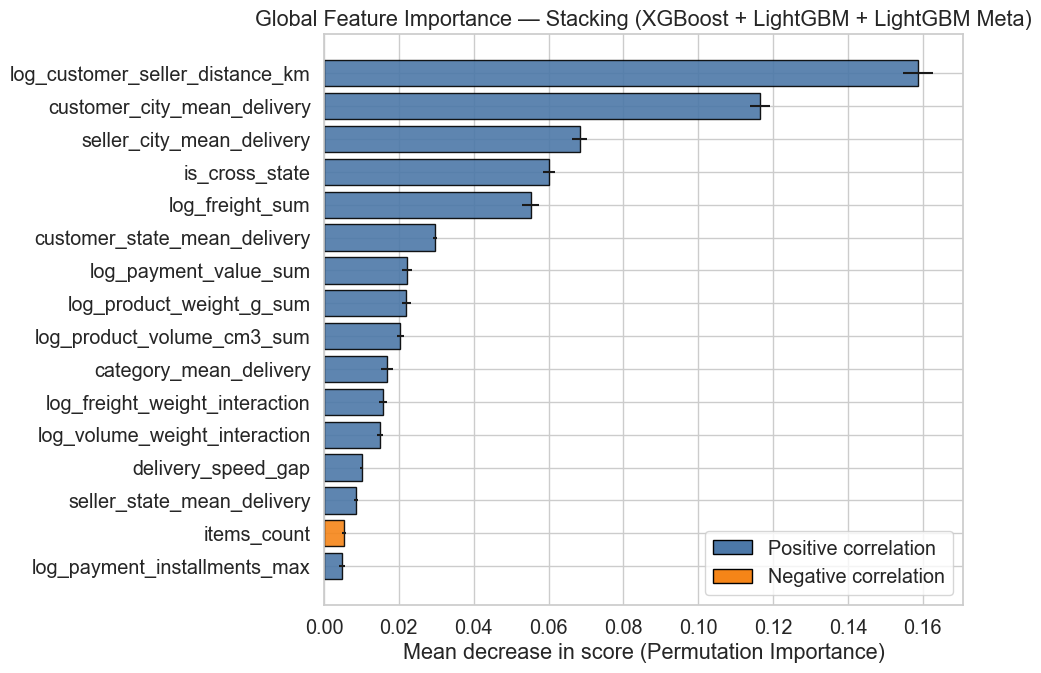

Top features (Permutation Importance):


,Importance,ImportanceStd,Direction
4,0.1587,0.0039,0.806
13,0.1164,0.0026,0.674
14,0.0684,0.0020,0.356
10,0.0601,0.0015,0.721
0,0.0553,0.0023,0.524
11,0.0297,0.0006,0.698
6,0.0223,0.0013,0.198
3,0.0220,0.0011,0.127
2,0.0205,0.0011,0.099
15,0.0169,0.0015,0.199


In [94]:
# -- Robust Feature Importance for Best/Fallback Model (no leaderboard needed) --

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.ensemble import StackingRegressor

# ---------------------------
# 0) Small helpers
# ---------------------------
def _pretty_name(cls_name: str) -> str:
    c = cls_name.lower()
    if "xgbregressor" in c: return "XGBoost"
    if "lgbmregressor" in c: return "LightGBM"
    if "linearregression" in c: return "Linear Regression"
    if "ridge" in c: return "Ridge"
    if "lasso" in c: return "Lasso"
    if "randomforestregressor" in c: return "Random Forest"
    return cls_name

def _stack_label(stack: StackingRegressor) -> str:
    base_names = []
    if hasattr(stack, "named_estimators_"):
        it = stack.named_estimators_.values()
    elif hasattr(stack, "estimators"):
        it = (est for _, est in stack.estimators)
    else:
        it = []
    for est in it:
        base_names.append(_pretty_name(type(est).__name__))
    meta_est = getattr(stack, "final_estimator_", None) or getattr(stack, "final_estimator", None)
    meta_name = _pretty_name(type(meta_est).__name__) if meta_est is not None else "Meta"
    base_part = " + ".join(base_names) if base_names else "Base"
    return f"Stacking ({base_part} + {meta_name} Meta)"

def _normalize_label(s: str) -> str:
    return " ".join(str(s).strip().lower().split())

def _safe_corr(a, b):
    a = np.asarray(a); b = np.asarray(b)
    if np.std(a) == 0 or np.std(b) == 0:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

# ---------------------------
# 1) Resolve dataset for evaluation
#    Prefer df_test_eval/X; fallback to training X/y
# ---------------------------
globals_snap = dict(globals())

if 'df_test_eval' in globals_snap and 'X' in globals_snap:
    X_eval = globals_snap['df_test_eval'].reindex(columns=globals_snap['X'].columns).apply(pd.to_numeric, errors='coerce').fillna(0)
    if 'log_delivery_time_days' in globals_snap['df_test_eval'].columns:
        y_eval_log = pd.to_numeric(globals_snap['df_test_eval']['log_delivery_time_days'], errors='coerce').fillna(0)
    elif 'y' in globals_snap:
        y_eval_log = pd.to_numeric(globals_snap['y'], errors='coerce').fillna(0)
        X_eval = globals_snap['X']  
    else:
        raise RuntimeError("No target found: need df_test_eval['log_delivery_time_days'] or training y.")
elif 'X' in globals_snap and 'y' in globals_snap:
    X_eval = globals_snap['X']
    y_eval_log = pd.to_numeric(globals_snap['y'], errors='coerce').fillna(0)
else:
    raise RuntimeError("Neither (df_test_eval & X) nor (X & y) are available for evaluation.")

# ---------------------------
# 2) Decide which fitted model to use
#    Priority: summary_df best -> final_stack -> any StackingRegressor found
# ---------------------------
best_name = None
if 'summary_df' in globals_snap and isinstance(globals_snap['summary_df'], pd.DataFrame):
    try:
        row = globals_snap['summary_df'].sort_values('MAE', ascending=True).iloc[0]
        best_name = str(row['Model'])
    except Exception:
        pass

model = None
if 'final_stack' in globals_snap and isinstance(globals_snap['final_stack'], StackingRegressor):
    model = globals_snap['final_stack']
    if best_name is None:
        best_name = _stack_label(model)

if model is None:
    candidates = []
    for nm, obj in globals_snap.items():
        if isinstance(obj, StackingRegressor):
            candidates.append((nm, obj, _stack_label(obj)))
    if best_name is not None:
        best_norm = _normalize_label(best_name)
        for nm, obj, label in candidates:
            if _normalize_label(label) == best_norm or best_norm in _normalize_label(label):
                model = obj
                break
    if model is None and candidates:
        # just take the first fitted one
        model = candidates[0][1]
        if best_name is None:
            best_name = candidates[0][2]

if model is None:
    raise RuntimeError("No fitted StackingRegressor found in memory (and no `final_stack`).")

print(f"[Info] Using model: {best_name or _stack_label(model)}")

# ---------------------------
# 3) Permutation Importance
# ---------------------------
perm = permutation_importance(
    model,
    X_eval,
    y_eval_log,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "Feature": X_eval.columns,
    "Importance": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("Importance", ascending=False)

# Direction (correlation with model prediction in log-space)
y_pred_log_eval = model.predict(X_eval)
imp_df["Direction"] = [ _safe_corr(X_eval[col], y_pred_log_eval) for col in imp_df["Feature"] ]
imp_df["Sign"] = np.where(imp_df["Direction"] >= 0, "Positive", "Negative")

# ---------------------------
# 4) Plot Top-K
# ---------------------------
TOP_K = 20
top = imp_df.head(TOP_K).iloc[::-1]

plt.figure(figsize=(10, 7))
colors = np.where(top["Sign"] == "Positive", "#4C78A8", "#F58518")
plt.barh(top["Feature"], top["Importance"], xerr=top["ImportanceStd"], alpha=0.9, ec="black", color=colors)
plt.xlabel("Mean decrease in score (Permutation Importance)")
plt.title(f"Global Feature Importance — {best_name or _stack_label(model)}")
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C78A8", edgecolor="black", label="Positive correlation"),
    Patch(facecolor="#F58518", edgecolor="black", label="Negative correlation"),
]
plt.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

print("Top features (Permutation Importance):")
try:
    from IPython.display import display
    display(top[["Importance", "ImportanceStd", "Direction"]].iloc[::-1].style.format({
        "Importance": "{:.4f}",
        "ImportanceStd": "{:.4f}",
        "Direction": "{:.3f}"
    }))
except Exception:
    print(top[["Importance", "ImportanceStd", "Direction"]].iloc[::-1].to_string(index=False))


We made evaluation on our final chosed model. The chart shows that the model relies on geographical features to predict delivery time. Variables such as regional and seller-level average delivery times (like  and ```seller_city_mean_delivery``` and ```customer_city_mean_delivery```)  and ```log_customer_seller_distance_km``` stand out as the most important, suggesting that how far the seller is from the customer are key drivers of delivery speed and reflect differences in fulfillment efficiency across areas. Other features, such as freight, weight, and volume, have a smaller impact on the final prediction.

In [65]:
import pandas as pd


# Step 1. Load predictions
INPUT_PATH = "clean_outputs/test_predictions_original_scale.csv"

df = pd.read_csv(INPUT_PATH)
print(df.shape)

# Step 2. Check columns
if "predicted_delivery_time_days" not in df.columns:
    raise KeyError("Missing required column: predicted_delivery_time_days")

# Step 3. Compute stats
mean_val = df["predicted_delivery_time_days"].mean()
median_val = df["predicted_delivery_time_days"].median()
std_val = df["predicted_delivery_time_days"].std()
min_val = df["predicted_delivery_time_days"].min()
max_val = df["predicted_delivery_time_days"].max()

# Step 4. Create summary DataFrame
summary = pd.DataFrame({
    "Statistic": ["Mean (Average)", "Median", "Standard Deviation", "Minimum", "Maximum"],
    "Predicted Delivery Time (days)": [mean_val, median_val, std_val, min_val, max_val]
})

# Step 5. Round and display
summary = summary.round(4)
print("\nOverall Predicted Delivery Time Summary:")
display(summary)

(18998, 1)

Overall Predicted Delivery Time Summary:


,Statistic,Predicted Delivery Time (days)
0,Mean (Average),11.0821
1,Median,10.7781
2,Standard Deviation,4.4837
3,Minimum,3.4651
4,Maximum,27.6806


Finally, we calculate Mean, Median and Standard Deviation to reflect the average delivery time prediction. This helps us understand the central tendency and variability of the predicted delivery duration, for example, most orders are expected to be delivered around 11 days, but with a standard deviation of about 4.5 days, meaning some deliveries may be noticeably faster or slower.

# **8. Error analysis**

Cross-validation results show that the Stacking model’s strong performance is stable and reproducible, demonstrating good generalization ability.
In contrast, the Linear Regression model systematically underestimates delivery time and shows heteroscedasticity, making its forecasts overly optimistic and increasing business risk.

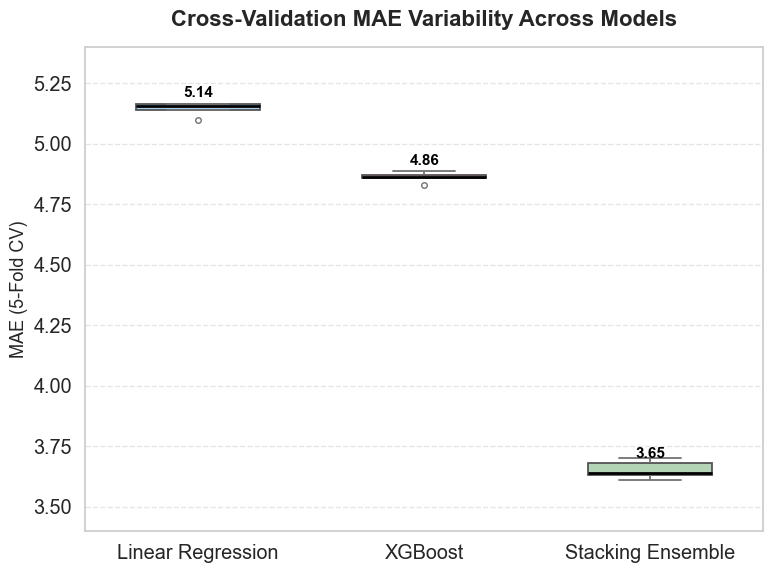

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cv_results = {
    'Linear Regression': [5.1652, 5.1644, 5.1392, 5.0958, 5.1555],
    'XGBoost': [4.8578, 4.8866, 4.8708, 4.8304, 4.8600],
    'Stacking Ensemble': [3.68, 3.63, 3.61, 3.70, 3.64]
}
df_cv = pd.DataFrame(cv_results)
df_melted = df_cv.melt(var_name='Model', value_name='MAE')

sns.set(style="whitegrid", font_scale=1.3)
palette = ["#90CAF9", "#F48FB1", "#A5D6A7"]

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x='Model', y='MAE', data=df_melted,
    palette=palette, width=0.55, linewidth=1.3,
    fliersize=4, boxprops=dict(alpha=0.9, edgecolor="#444"),
    medianprops=dict(color="black", linewidth=2)
)

plt.title("Cross-Validation MAE Variability Across Models",
          fontsize=16, weight='bold', pad=15)
plt.ylabel("MAE (5-Fold CV)", fontsize=13)
plt.xlabel("")
plt.ylim(3.4, 5.4)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

means = df_cv.mean()
for i, model in enumerate(df_cv.columns):
    ax.text(i, means[model] + 0.05, f"{means[model]:.2f}",
            ha='center', fontsize=11, color='black', weight='bold')

plt.show()


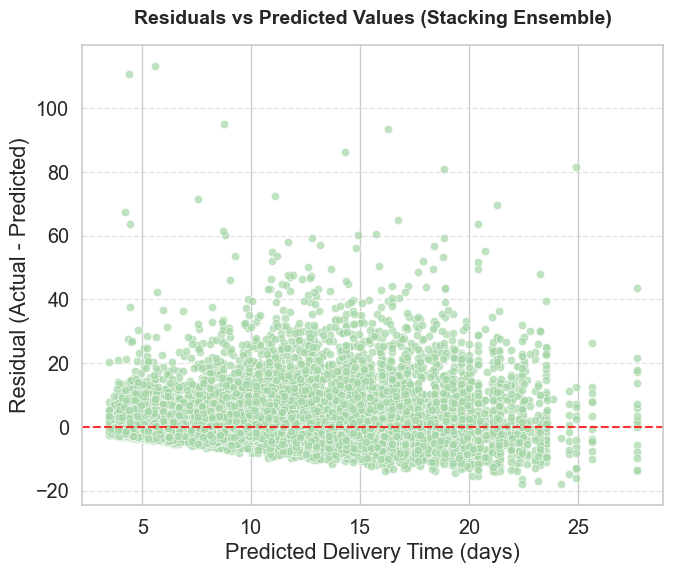

In [69]:
#Residual Plot-- XGBoost + LightGBM Stacking (meta = LightGBM)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TRUE_PATH = "clean_outputs/final_test_transformed_with_log_y.csv"
PRED_PATH = "clean_outputs/test_predictions_original_scale.csv"

df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)

df = pd.DataFrame({
    "y_true": df_true['delivery_time_days'],
    "y_pred_stack": df_pred['predicted_delivery_time_days']
})
df["Stacking Ensemble"] = df["y_true"] - df["y_pred_stack"]

plt.figure(figsize=(7, 6))
sns.scatterplot(x='y_pred_stack', y='Stacking Ensemble', data=df, alpha=0.7, color=palette[2])
plt.axhline(0, color='red', linestyle='--', alpha=0.8)
plt.title("Residuals vs Predicted Values (Stacking Ensemble)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Predicted Delivery Time (days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

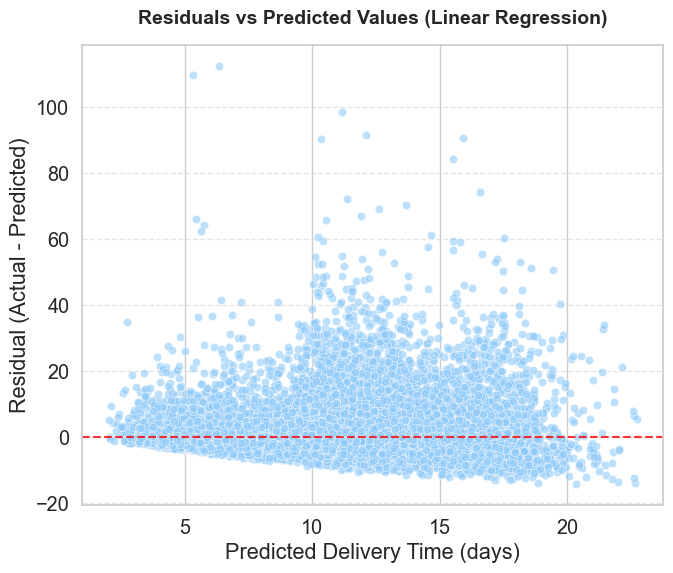

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

csv_path = "clean_outputs/linear_test_eval_predictions_vs_truth.csv"
df = pd.read_csv(csv_path)

required_cols = {"y_true_days", "y_pred_days", "residual_days"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

plt.figure(figsize=(7, 6))
sns.scatterplot(x="y_pred_days", y="residual_days", data=df, alpha=0.6, color=palette[0])
plt.axhline(0, color="red", linestyle="--", alpha=0.8)
plt.title("Residuals vs Predicted Values (Linear Regression)", fontsize=14, weight="bold", pad=15)
plt.xlabel("Predicted Delivery Time (days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

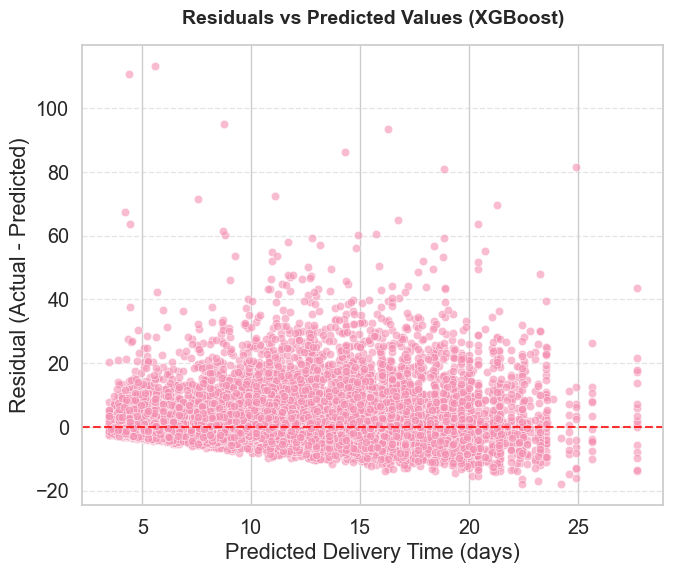

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TRUE_PATH = "clean_outputs/final_test_transformed_with_log_y.csv"
PRED_PATH = "clean_outputs/test_predictions_original_scale.csv"

df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)

df = pd.DataFrame({
    "y_true_days": df_true["delivery_time_days"],
    "y_pred_days": df_pred["predicted_delivery_time_days"]
})
df["residual_days"] = df["y_true_days"] - df["y_pred_days"]

out_path = "clean_outputs/xgb_test_eval_predictions_vs_truth.csv"
df.to_csv(out_path, index=False, encoding="utf-8-sig")

plt.figure(figsize=(7, 6))
sns.scatterplot(x="y_pred_days", y="residual_days", data=df, alpha=0.6, color=palette[1])
plt.axhline(0, color="red", linestyle="--", alpha=0.8)
plt.title("Residuals vs Predicted Values (XGBoost)", fontsize=14, weight="bold", pad=15)
plt.xlabel("Predicted Delivery Time (days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
